In [1]:
# ============================================================
# VOLTRELAY ENERGY — DATA ANALYTICS HACKATHON
# Data Loading & Initial Setup
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

# Plot settings
sns.set_theme(style="whitegrid")

# ============================================================
# PROJECT PATHS
# ============================================================

# Project root = parent of the notebooks folder
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHARTS_DIR = OUTPUT_DIR / "charts"
TABLES_DIR = OUTPUT_DIR / "tables"

# Create output folders if they don't exist
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:")
print(PROJECT_ROOT)

print("\nData folder:")
print(DATA_DIR)

print("\nOutput folder:")
print(OUTPUT_DIR)

Project root:
c:\Users\lalit\OneDrive\ACHI_BCOM\VoltRelay_Hackathon

Data folder:
c:\Users\lalit\OneDrive\ACHI_BCOM\VoltRelay_Hackathon\data

Output folder:
c:\Users\lalit\OneDrive\ACHI_BCOM\VoltRelay_Hackathon\outputs


In [2]:
# ============================================================
# LOAD SUPPORTING DATASETS
# ============================================================

stations = pd.read_csv(
    DATA_DIR / "stations.csv",
    low_memory=False
)

city_context = pd.read_csv(
    DATA_DIR / "city_daily_context.csv",
    low_memory=False
)

fleet_partners = pd.read_csv(
    DATA_DIR / "fleet_partners.csv",
    low_memory=False
)

batteries = pd.read_csv(
    DATA_DIR / "batteries.csv",
    low_memory=False
)

riders = pd.read_csv(
    DATA_DIR / "riders.csv",
    low_memory=False
)

station_hourly = pd.read_csv(
    DATA_DIR / "station_hourly_status.csv",
    low_memory=False
)

support_tickets = pd.read_csv(
    DATA_DIR / "support_tickets.csv",
    low_memory=False
)

print("All supporting datasets loaded successfully! ✅")

All supporting datasets loaded successfully! ✅


In [3]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

datasets = {
    "Stations": stations,
    "City Daily Context": city_context,
    "Fleet Partners": fleet_partners,
    "Batteries": batteries,
    "Riders": riders,
    "Station Hourly Status": station_hourly,
    "Support Tickets": support_tickets
}

overview = []

for name, df in datasets.items():
    overview.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": int(df.isna().sum().sum()),
        "Duplicate Rows": int(df.duplicated().sum())
    })

dataset_overview = pd.DataFrame(overview)

dataset_overview

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Stations,152,22,293,0
1,City Daily Context,3282,12,3172,0
2,Fleet Partners,12,12,22,0
3,Batteries,6500,13,10124,0
4,Riders,20000,12,12837,0
5,Station Hourly Status,1487712,14,896880,0
6,Support Tickets,44000,12,50445,0


In [4]:
# ============================================================
# COLUMN INFORMATION
# ============================================================

for name, df in datasets.items():

    print("\n" + "=" * 80)
    print(name.upper())
    print("=" * 80)

    print(f"Shape: {df.shape}")

    print("\nColumns:")
    for col in df.columns:
        print(f"  • {col}")


STATIONS
Shape: (152, 22)

Columns:
  • station_id
  • city
  • zone
  • latitude
  • longitude
  • location_type
  • host_type
  • commissioned_date
  • decommissioned_date
  • expansion_wave
  • charger_generation
  • slots_2w
  • slots_3w
  • inventory_target_2w
  • inventory_target_3w
  • monthly_rent_inr
  • monthly_maintenance_inr
  • grid_tariff_inr_kwh
  • connectivity_tier
  • firmware_version
  • firmware_updated_date
  • competitor_within_1_5km_since

CITY DAILY CONTEXT
Shape: (3282, 12)

Columns:
  • city
  • date
  • max_temp_c
  • min_temp_c
  • rainfall_mm
  • heat_alert
  • flood_disruption
  • festival_or_event
  • is_public_holiday
  • grid_outage_hours
  • competitor_promo_active
  • ecommerce_sale_event

FLEET PARTNERS
Shape: (12, 12)

Columns:
  • partner_id
  • partner_name
  • partner_segment
  • vehicle_class
  • contract_type
  • contract_start_date
  • discount_pct
  • amendment_date
  • discount_pct_after_amendment
  • peak_surcharge_billable
  • payment_ter

In [6]:
# ============================================================
# INSPECT LARGE SWAP EVENTS FILE
# ============================================================

SWAP_FILE = DATA_DIR / "swap_events.csv"

print("Swap file:")
print(SWAP_FILE)

# Read only a small sample
swap_sample = pd.read_csv(
    SWAP_FILE,
    
    nrows=5
)

print("\nShape of sample:", swap_sample.shape)

print("\nColumns:")
print(swap_sample.columns.tolist())

print("\nSample:")
display(swap_sample)

Swap file:
c:\Users\lalit\OneDrive\ACHI_BCOM\VoltRelay_Hackathon\data\swap_events.csv

Shape of sample: (5, 22)

Columns:
['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode']

Sample:


,event_id,rider_id,station_id,event_ts,event_type,attempt_seq,queue_wait_sec,battery_in_id,battery_out_id,soc_in_pct,soh_in_pct,soc_out_pct,soh_out_pct,km_since_last_swap,tariff_code,list_price_inr,discount_inr,amount_charged_inr,payment_mode,energy_to_recharge_kwh,station_firmware,sync_mode
0,SW-000000001,RD-1000003,STN-MUM-115,2024-01-01 11:10:56,swap_completed,1,88,BAT-2W-103542,BAT-2W-102547,15.0,100.6,98.7,98.9,80.4,PARTNER,60.0,6.0,54.0,partner_invoice,2.035,v3.2.1,realtime
1,SW-000000002,RD-1000004,STN-HYD-070,2024-01-01 17:13:06,swap_completed,1,148,BAT-2W-105296,BAT-2W-101923,8.3,98.3,97.3,98.2,66.1,PARTNER,60.0,9.0,51.0,partner_invoice,2.157,v3.2.0,realtime
2,SW-000000003,RD-1000005,STN-DEL-046,2024-01-01 20:15:14,swap_completed,1,307,BAT-2W-104732,BAT-2W-102492,11.5,99.1,99.8,99.1,66.6,STD,60.0,0.0,60.0,partner_invoice,2.039,v3.2.0,realtime
3,SW-000000004,RD-1000006,STN-JAI-135,2024-01-01 20:26:07,swap_completed,1,399,BAT-2W-103839,BAT-2W-103267,7.9,99.6,98.4,98.2,65.4,STD,60.0,0.0,60.0,partner_invoice,2.194,v3.2.0,realtime
4,SW-000000005,RD-1000012,STN-PUN-100,2024-01-01 21:13:07,swap_completed,1,201,BAT-2W-104056,BAT-2W-106218,10.5,99.2,95.6,99.9,73.8,STD,60.0,0.0,60.0,partner_invoice,1.971,v3.2.1,realtime


In [7]:
# ============================================================
# VERIFY LARGE FILE
# ============================================================

if SWAP_FILE.exists():

    file_size_gb = SWAP_FILE.stat().st_size / (1024 ** 3)

    print("✅ swap_events.csv found!")
    print(f"Compressed file size: {file_size_gb:.2f} GB")

else:

    print("❌ swap_events.csv.gz was not found.")
    print("Check that it is inside the data folder.")

✅ swap_events.csv found!
Compressed file size: 0.68 GB


# VoltRelay Energy — Data Analytics Hackathon

## 1. Business Objective
## 2. Data Overview & Quality
## 3. Network Performance
## 4. Service Failures & Customer Experience
## 5. Station & Geographic Analysis
## 6. Battery & Equipment Analysis
## 7. Pricing & Partner Economics
## 8. Rider Retention
## 9. Key Findings & Recommendations
## 10. Final Conclusion

In [21]:
# ============================================================
# IMPORT PROJECT CLEANING FUNCTIONS
# ============================================================

import sys
import importlib
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_cleaning import (
    quality_summary,
    duplicate_summary,
    standardize_city_names,
    convert_datetime,
    remove_exact_duplicates,
    missing_value_summary
)

import src.metrics as metrics_module
importlib.reload(metrics_module)

from src.metrics import (
    calculate_swap_metrics,
    calculate_failure_rate,
    calculate_margin_per_swap,
    process_swap_file
)

print("Metric functions imported successfully! ✅")

print("Cleaning functions imported successfully! ✅")

Metric functions imported successfully! ✅
Cleaning functions imported successfully! ✅


In [9]:
# ============================================================
# SECTION 2 — DATA QUALITY CHECK
# ============================================================

quality_results = {}

for name, df in datasets.items():
    quality_results[name] = quality_summary(df, name)

    print("\n" + "=" * 80)
    print(name.upper())
    print("=" * 80)

    display(quality_results[name])


STATIONS


,Dataset,Column,Data Type,Missing Count,Missing %,Unique Values
0,Stations,station_id,str,0,0.00,152
1,Stations,city,str,0,0.00,6
2,Stations,zone,str,0,0.00,28
3,Stations,latitude,float64,0,0.00,151
4,Stations,longitude,float64,0,0.00,151
5,Stations,location_type,str,0,0.00,6
6,Stations,host_type,str,0,0.00,4
7,Stations,commissioned_date,str,0,0.00,117
8,Stations,decommissioned_date,str,151,99.34,1
9,Stations,expansion_wave,str,0,0.00,3



CITY DAILY CONTEXT


,Dataset,Column,Data Type,Missing Count,Missing %,Unique Values
0,City Daily Context,city,str,0,0.00,6
1,City Daily Context,date,str,0,0.00,547
2,City Daily Context,max_temp_c,float64,0,0.00,402
3,City Daily Context,min_temp_c,float64,0,0.00,194
4,City Daily Context,rainfall_mm,float64,0,0.00,407
5,City Daily Context,heat_alert,bool,0,0.00,2
6,City Daily Context,flood_disruption,bool,0,0.00,2
7,City Daily Context,festival_or_event,str,3172,96.65,5
8,City Daily Context,is_public_holiday,bool,0,0.00,2
9,City Daily Context,grid_outage_hours,float64,0,0.00,15



FLEET PARTNERS


...

,Dataset,Column,Data Type,Missing Count,Missing %,Unique Values
0,Riders,rider_id,str,0,0.00,20000
1,Riders,partner_id,str,7628,38.14,12
2,Riders,vehicle_class,str,0,0.00,2
3,Riders,vehicle_model,str,0,0.00,8
4,Riders,home_zone,str,0,0.00,28
5,Riders,signup_date,str,0,0.00,817
6,Riders,signup_channel,str,0,0.00,4
7,Riders,plan_type,str,0,0.00,3
8,Riders,declared_shift,str,3662,18.31,4
9,Riders,age_band,str,1547,7.74,4



STATION HOURLY STATUS


,Dataset,Column,Data Type,Missing Count,Missing %,Unique Values
0,Station Hourly Status,station_id,str,0,0.00,152
1,Station Hourly Status,hour_start,str,0,0.00,13128
2,Station Hourly Status,charged_2w_avg,float64,9384,0.63,2250
3,Station Hourly Status,charged_2w_min,float64,9384,0.63,23
4,Station Hourly Status,charged_3w_min,float64,821808,55.24,6
5,Station Hourly Status,packs_charging,float64,9384,0.63,23
6,Station Hourly Status,packs_quarantined,float64,9384,0.63,3
7,Station Hourly Status,chargers_online,int64,0,0.00,16
8,Station Hourly Status,ambient_temp_c,float64,9384,0.63,472
9,Station Hourly Status,cabinet_temp_c,float64,9384,0.63,541



SUPPORT TICKETS


,Dataset,Column,Data Type,Missing Count,Missing %,Unique Values
0,Support Tickets,ticket_id,str,0,0.00,44000
1,Support Tickets,rider_id,str,0,0.00,13979
2,Support Tickets,station_id,str,2227,5.06,152
3,Support Tickets,battery_id,str,13235,30.08,6428
4,Support Tickets,created_ts,str,0,0.00,43969
5,Support Tickets,channel,str,0,0.00,4
6,Support Tickets,category,str,0,0.00,6
7,Support Tickets,rider_comment,str,0,0.00,89
8,Support Tickets,priority,str,0,0.00,3
9,Support Tickets,resolution_status,str,0,0.00,3


In [10]:
# ============================================================
# DUPLICATE CHECK
# ============================================================

duplicate_results = []

for name, df in datasets.items():
    duplicate_results.append(
        duplicate_summary(df, name)
    )

duplicate_results = pd.DataFrame(duplicate_results)

display(duplicate_results)

,Dataset,Total Rows,Duplicate Rows,Duplicate %
0,Stations,152,0,0.0
1,City Daily Context,3282,0,0.0
2,Fleet Partners,12,0,0.0
3,Batteries,6500,0,0.0
4,Riders,20000,0,0.0
5,Station Hourly Status,1487712,0,0.0
6,Support Tickets,44000,0,0.0


In [14]:
# ============================================================
# CHECK DATA FOLDER
# ============================================================

print("Data folder:")
print(DATA_DIR)

print("\nFiles currently inside data folder:")

for file in DATA_DIR.iterdir():
    print(" -", file.name)

Data folder:
c:\Users\lalit\OneDrive\ACHI_BCOM\VoltRelay_Hackathon\data

Files currently inside data folder:
 - batteries.csv
 - city_daily_context.csv
 - fleet_partners.csv
 - riders.csv
 - stations.csv
 - station_hourly_status.csv
 - support_tickets.csv
 - swap_events.csv


In [22]:
# ============================================================
# PROCESS LARGE SWAP EVENTS DATASET
# ============================================================

SWAP_FILE = DATA_DIR / "swap_events.csv"

swap_metrics = process_swap_file(
    SWAP_FILE,
    chunksize=250_000
)

print("\n" + "=" * 70)
print("VOLTRELAY NETWORK PERFORMANCE — INITIAL RESULTS")
print("=" * 70)

print(f"Total swap attempts : {swap_metrics['total_attempts']:,}")
print(f"Completed swaps     : {swap_metrics['completed_swaps']:,}")
print(f"Failed swaps        : {swap_metrics['failed_swaps']:,}")
print(f"Abandoned swaps     : {swap_metrics['abandoned_swaps']:,}")
print(f"Failure rate        : {swap_metrics['failure_rate_pct']:.2f}%")
print(f"Chunks processed    : {swap_metrics['chunks_processed']}")

Processed chunk 1 | Rows processed: 250,000
Processed chunk 2 | Rows processed: 500,000
Processed chunk 3 | Rows processed: 750,000
Processed chunk 4 | Rows processed: 1,000,000
Processed chunk 5 | Rows processed: 1,250,000
Processed chunk 6 | Rows processed: 1,500,000
Processed chunk 7 | Rows processed: 1,750,000
Processed chunk 8 | Rows processed: 2,000,000
Processed chunk 9 | Rows processed: 2,250,000
Processed chunk 10 | Rows processed: 2,500,000
Processed chunk 11 | Rows processed: 2,750,000
Processed chunk 12 | Rows processed: 3,000,000
Processed chunk 13 | Rows processed: 3,250,000
Processed chunk 14 | Rows processed: 3,500,000
Processed chunk 15 | Rows processed: 3,750,000
Processed chunk 16 | Rows processed: 3,877,013

VOLTRELAY NETWORK PERFORMANCE — INITIAL RESULTS
Total swap attempts : 3,877,013
Completed swaps     : 0
Failed swaps        : 0
Abandoned swaps     : 0
Failure rate        : 0.00%
Chunks processed    : 16


In [23]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
swap_file = PROJECT_ROOT / "data" / "swap_events.csv"

sample = pd.read_csv(
    swap_file,
    nrows=100000,
    low_memory=False
)

print("Columns:")
print(sample.columns.tolist())

print("\nEvent Type values:")
print(sample["event_type"].value_counts(dropna=False))

print("\nUnique event types:")
print(sample["event_type"].dropna().unique())

Columns:
['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode']

Event Type values:
event_type
swap_completed               95592
failed_no_charged_battery     2441
abandoned_queue               1267
cancelled_by_rider             407
failed_system_error            293
Name: count, dtype: int64

Unique event types:
<ArrowStringArray>
['swap_completed', 'failed_no_charged_battery', 'cancelled_by_rider', 'abandoned_queue', 'failed_system_error']
Length: 5, dtype: str


In [24]:
import importlib
import src.metrics

importlib.reload(src.metrics)

from src.metrics import process_swap_file

print("metrics.py reloaded successfully! ✅")

metrics.py reloaded successfully! ✅


In [25]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

swap_file = PROJECT_ROOT / "data" / "swap_events.csv"

results = process_swap_file(swap_file)

print("\n" + "=" * 70)
print("VOLTRELAY NETWORK PERFORMANCE")
print("=" * 70)

print(f"Total swap attempts        : {results['total_attempts']:,}")
print(f"Completed swaps            : {results['completed_swaps']:,}")
print(f"Failed swaps               : {results['failed_swaps']:,}")
print(f"  - No charged battery     : {results['failed_no_charged_battery']:,}")
print(f"  - System error           : {results['failed_system_error']:,}")
print(f"Abandoned queue            : {results['abandoned_swaps']:,}")
print(f"Cancelled by rider         : {results['cancelled_swaps']:,}")
print(f"Unsuccessful attempts      : {results['unsuccessful_attempts']:,}")
print(f"Failure / loss rate        : {results['failure_rate_pct']:.2f}%")
print(f"Chunks processed           : {results['chunks_processed']}")

Processed chunk 1 | Rows processed: 250,000
Processed chunk 2 | Rows processed: 500,000
Processed chunk 3 | Rows processed: 750,000
Processed chunk 4 | Rows processed: 1,000,000
Processed chunk 5 | Rows processed: 1,250,000
Processed chunk 6 | Rows processed: 1,500,000
Processed chunk 7 | Rows processed: 1,750,000
Processed chunk 8 | Rows processed: 2,000,000
Processed chunk 9 | Rows processed: 2,250,000
Processed chunk 10 | Rows processed: 2,500,000
Processed chunk 11 | Rows processed: 2,750,000
Processed chunk 12 | Rows processed: 3,000,000
Processed chunk 13 | Rows processed: 3,250,000
Processed chunk 14 | Rows processed: 3,500,000
Processed chunk 15 | Rows processed: 3,750,000
Processed chunk 16 | Rows processed: 3,877,013

VOLTRELAY NETWORK PERFORMANCE
Total swap attempts        : 3,877,013
Completed swaps            : 3,645,809
Failed swaps               : 145,959
  - No charged battery     : 134,389
  - System error           : 11,570
Abandoned queue            : 68,533
Cancelle

In [26]:
# ============================================================
# 3. NETWORK PERFORMANCE — MONTHLY ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
swap_file = PROJECT_ROOT / "data" / "swap_events.csv"

monthly_parts = []

for chunk in pd.read_csv(
    swap_file,
    chunksize=250_000,
    low_memory=False
):
    
    # Convert timestamp
    chunk["event_ts"] = pd.to_datetime(
        chunk["event_ts"],
        errors="coerce"
    )
    
    # Create month
    chunk["month"] = chunk["event_ts"].dt.to_period("M").astype(str)
    
    # Standardize event type
    chunk["event_type"] = (
        chunk["event_type"]
        .astype("string")
        .str.strip()
        .str.lower()
    )
    
    # Flags
    chunk["completed"] = (
        chunk["event_type"] == "swap_completed"
    ).astype(int)
    
    chunk["failed"] = chunk["event_type"].isin([
        "failed_no_charged_battery",
        "failed_system_error"
    ]).astype(int)
    
    chunk["abandoned"] = (
        chunk["event_type"] == "abandoned_queue"
    ).astype(int)
    
    chunk["cancelled"] = (
        chunk["event_type"] == "cancelled_by_rider"
    ).astype(int)
    
    # Revenue only from completed swaps
    chunk["completed_revenue"] = np.where(
        chunk["event_type"] == "swap_completed",
        pd.to_numeric(
            chunk["amount_charged_inr"],
            errors="coerce"
        ),
        0
    )
    
    # Aggregate chunk
    monthly = (
        chunk.groupby("month")
        .agg(
            total_attempts=("event_id", "count"),
            completed_swaps=("completed", "sum"),
            failed_swaps=("failed", "sum"),
            abandoned_swaps=("abandoned", "sum"),
            cancelled_swaps=("cancelled", "sum"),
            revenue_inr=("completed_revenue", "sum")
        )
        .reset_index()
    )
    
    monthly_parts.append(monthly)


# Combine all chunk summaries
monthly_network = (
    pd.concat(monthly_parts, ignore_index=True)
    .groupby("month", as_index=False)
    .sum()
)

# Calculate rates
monthly_network["unsuccessful_attempts"] = (
    monthly_network["failed_swaps"]
    + monthly_network["abandoned_swaps"]
    + monthly_network["cancelled_swaps"]
)

monthly_network["failure_rate_pct"] = (
    monthly_network["unsuccessful_attempts"]
    / monthly_network["total_attempts"]
    * 100
)

monthly_network["completion_rate_pct"] = (
    monthly_network["completed_swaps"]
    / monthly_network["total_attempts"]
    * 100
)

monthly_network["revenue_per_completed_swap_inr"] = (
    monthly_network["revenue_inr"]
    / monthly_network["completed_swaps"]
)

# Sort chronologically
monthly_network = monthly_network.sort_values("month")

# Display
monthly_network

,month,total_attempts,completed_swaps,failed_swaps,abandoned_swaps,cancelled_swaps,revenue_inr,unsuccessful_attempts,failure_rate_pct,completion_rate_pct,revenue_per_completed_swap_inr
0,2024-01,110348,105490,3008,1405,445,6318995.20,4858,4.402436,95.597564,59.901367
1,2024-02,111531,106582,3027,1451,471,6387614.80,4949,4.437331,95.562669,59.931459
2,2024-03,123900,118444,3332,1575,549,7093617.00,5456,4.403551,95.596449,59.890049
3,2024-04,131818,122836,5775,2683,524,7370255.80,8982,6.813940,93.186060,60.000780
4,2024-05,146278,128328,11760,5520,670,7689594.00,17950,12.271155,87.728845,59.921405
5,2024-06,148888,133743,9911,4596,638,8003275.60,15145,10.172076,89.827924,59.840706
6,2024-07,158688,151824,4186,2025,653,9879524.60,6864,4.325469,95.674531,65.072219
7,2024-08,172295,164931,4424,2185,755,10724296.65,7364,4.274065,95.725935,65.022929
8,2024-09,195885,187302,5311,2442,830,12115209.50,8583,4.381653,95.618347,64.682756
9,2024-10,229901,219838,6148,2904,1011,14577271.65,10063,4.377101,95.622899,66.309153


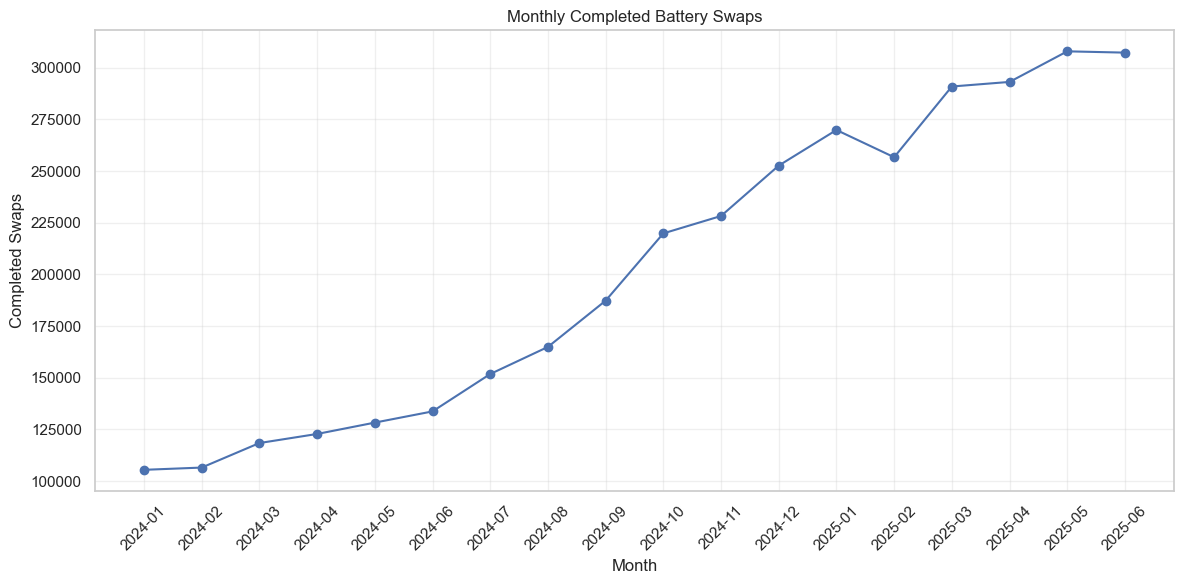

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_network["month"],
    monthly_network["completed_swaps"],
    marker="o"
)

plt.title("Monthly Completed Battery Swaps")
plt.xlabel("Month")
plt.ylabel("Completed Swaps")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()

chart_dir = PROJECT_ROOT / "outputs" / "charts"
chart_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    chart_dir / "monthly_completed_swaps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
# ============================================================
# MONTHLY NETWORK PERFORMANCE — SUMMARY
# ============================================================

display(
    monthly_network[
        [
            "month",
            "total_attempts",
            "completed_swaps",
            "failed_swaps",
            "abandoned_swaps",
            "cancelled_swaps",
            "unsuccessful_attempts",
            "failure_rate_pct",
            "completion_rate_pct",
            "revenue_inr",
            "revenue_per_completed_swap_inr"
        ]
    ].round(2)
)

,month,total_attempts,completed_swaps,failed_swaps,abandoned_swaps,cancelled_swaps,unsuccessful_attempts,failure_rate_pct,completion_rate_pct,revenue_inr,revenue_per_completed_swap_inr
0,2024-01,110348,105490,3008,1405,445,4858,4.40,95.60,6318995.20,59.90
1,2024-02,111531,106582,3027,1451,471,4949,4.44,95.56,6387614.80,59.93
2,2024-03,123900,118444,3332,1575,549,5456,4.40,95.60,7093617.00,59.89
3,2024-04,131818,122836,5775,2683,524,8982,6.81,93.19,7370255.80,60.00
4,2024-05,146278,128328,11760,5520,670,17950,12.27,87.73,7689594.00,59.92
5,2024-06,148888,133743,9911,4596,638,15145,10.17,89.83,8003275.60,59.84
6,2024-07,158688,151824,4186,2025,653,6864,4.33,95.67,9879524.60,65.07
7,2024-08,172295,164931,4424,2185,755,7364,4.27,95.73,10724296.65,65.02
8,2024-09,195885,187302,5311,2442,830,8583,4.38,95.62,12115209.50,64.68
9,2024-10,229901,219838,6148,2904,1011,10063,4.38,95.62,14577271.65,66.31


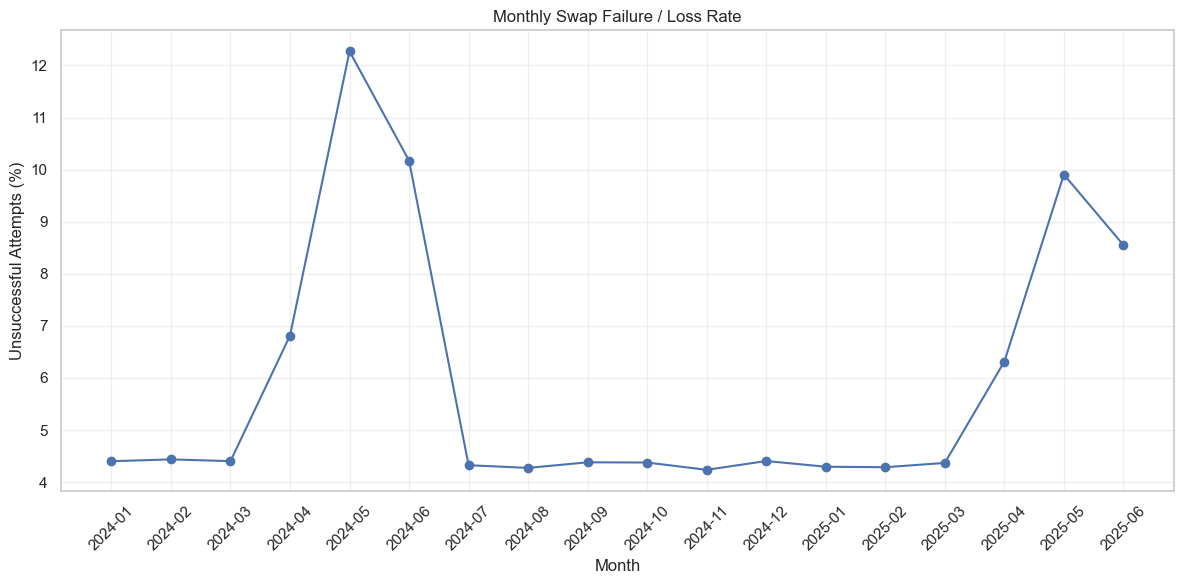

In [29]:
# ============================================================
# MONTHLY FAILURE / LOSS RATE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_network["month"],
    monthly_network["failure_rate_pct"],
    marker="o"
)

plt.title("Monthly Swap Failure / Loss Rate")
plt.xlabel("Month")
plt.ylabel("Unsuccessful Attempts (%)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    chart_dir / "monthly_failure_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

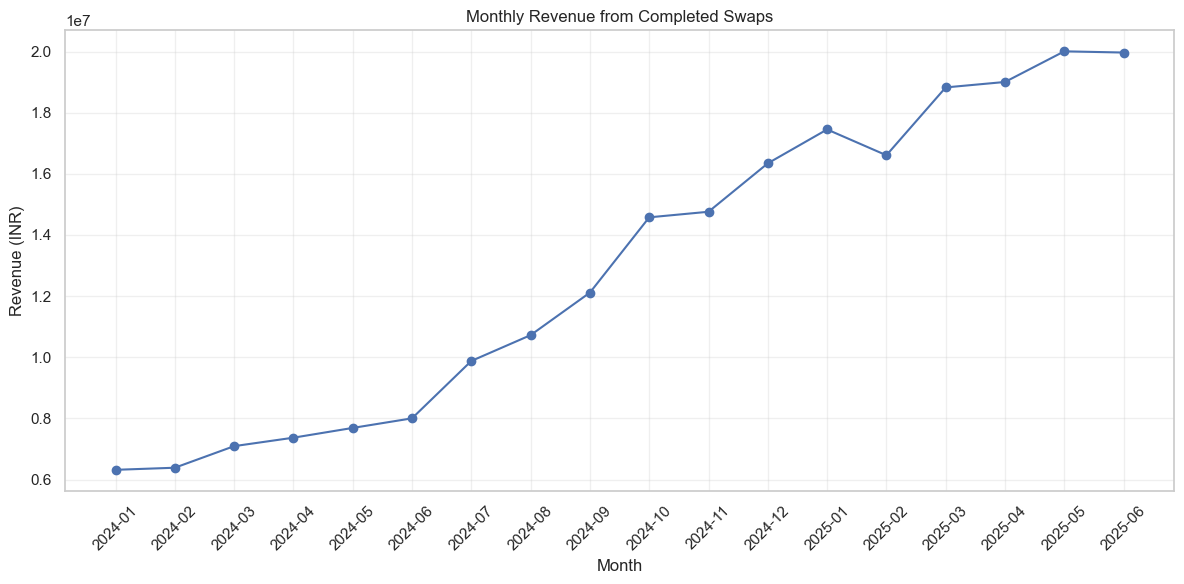

In [30]:
# ============================================================
# MONTHLY REVENUE
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_network["month"],
    monthly_network["revenue_inr"],
    marker="o"
)

plt.title("Monthly Revenue from Completed Swaps")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    chart_dir / "monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
# ============================================================
# 4. SERVICE FAILURES — STATION & HOUR ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
swap_file = PROJECT_ROOT / "data" / "swap_events.csv"

station_hour_parts = []

for chunk in pd.read_csv(
    swap_file,
    chunksize=250_000,
    low_memory=False
):

    # Convert timestamp
    chunk["event_ts"] = pd.to_datetime(
        chunk["event_ts"],
        errors="coerce"
    )

    # Extract hour
    chunk["hour"] = chunk["event_ts"].dt.hour

    # Standardize event type
    chunk["event_type"] = (
        chunk["event_type"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    # Event flags
    chunk["completed"] = (
        chunk["event_type"] == "swap_completed"
    ).astype(int)

    chunk["failed_no_battery"] = (
        chunk["event_type"] == "failed_no_charged_battery"
    ).astype(int)

    chunk["failed_system"] = (
        chunk["event_type"] == "failed_system_error"
    ).astype(int)

    chunk["abandoned"] = (
        chunk["event_type"] == "abandoned_queue"
    ).astype(int)

    chunk["cancelled"] = (
        chunk["event_type"] == "cancelled_by_rider"
    ).astype(int)

    # All unsuccessful attempts
    chunk["unsuccessful"] = (
        chunk["event_type"].isin([
            "failed_no_charged_battery",
            "failed_system_error",
            "abandoned_queue",
            "cancelled_by_rider"
        ])
    ).astype(int)

    # Aggregate by station and hour
    summary = (
        chunk.groupby(
            ["station_id", "hour"]
        )
        .agg(
            total_attempts=("event_id", "count"),
            completed_swaps=("completed", "sum"),
            failed_no_battery=("failed_no_battery", "sum"),
            failed_system=("failed_system", "sum"),
            abandoned=("abandoned", "sum"),
            cancelled=("cancelled", "sum"),
            unsuccessful=("unsuccessful", "sum"),
            avg_queue_wait_sec=("queue_wait_sec", "mean")
        )
        .reset_index()
    )

    station_hour_parts.append(summary)


# Combine chunk-level summaries
station_hour = (
    pd.concat(
        station_hour_parts,
        ignore_index=True
    )
    .groupby(
        ["station_id", "hour"],
        as_index=False
    )
    .agg(
        total_attempts=("total_attempts", "sum"),
        completed_swaps=("completed_swaps", "sum"),
        failed_no_battery=("failed_no_battery", "sum"),
        failed_system=("failed_system", "sum"),
        abandoned=("abandoned", "sum"),
        cancelled=("cancelled", "sum"),
        unsuccessful=("unsuccessful", "sum")
    )
)

# Calculate unsuccessful rate
station_hour["failure_rate_pct"] = (
    station_hour["unsuccessful"]
    / station_hour["total_attempts"]
    * 100
)

# Save result
output_dir = PROJECT_ROOT / "outputs" / "tables"
output_dir.mkdir(parents=True, exist_ok=True)

station_hour.to_csv(
    output_dir / "station_hour_failure_analysis.csv",
    index=False
)

print("Station-hour analysis completed! ✅")
print(
    f"Rows generated: {len(station_hour):,}"
)

display(
    station_hour.head(20)
)

Station-hour analysis completed! ✅
Rows generated: 3,648


,station_id,hour,total_attempts,completed_swaps,failed_no_battery,failed_system,abandoned,cancelled,unsuccessful,failure_rate_pct
0,STN-BLR-001,0,161,157,3,0,1,0,4,2.484472
1,STN-BLR-001,1,143,133,4,0,4,2,10,6.993007
2,STN-BLR-001,2,144,136,5,0,3,0,8,5.555556
3,STN-BLR-001,3,157,151,4,1,1,0,6,3.821656
4,STN-BLR-001,4,210,203,3,1,3,0,7,3.333333
5,STN-BLR-001,5,194,185,5,1,3,0,9,4.639175
6,STN-BLR-001,6,370,348,11,3,7,1,22,5.945946
7,STN-BLR-001,7,387,372,6,2,5,2,15,3.875969
8,STN-BLR-001,8,1132,1071,36,3,19,3,61,5.388693
9,STN-BLR-001,9,1519,1451,43,1,20,4,68,4.476629


In [32]:
# ============================================================
# TOP STATION-HOUR FAILURE RATES
# ============================================================

top_station_hours = (
    station_hour[
        station_hour["total_attempts"] >= 500
    ]
    .sort_values(
        "failure_rate_pct",
        ascending=False
    )
    .head(20)
)

display(top_station_hours)

,station_id,hour,total_attempts,completed_swaps,failed_no_battery,failed_system,abandoned,cancelled,unsuccessful,failure_rate_pct
885,STN-DEL-037,21,2933,2579,238,7,100,9,354,12.069553
934,STN-DEL-039,22,1583,1393,127,4,48,11,190,12.002527
884,STN-DEL-037,20,3706,3262,286,7,136,15,444,11.980572
2134,STN-JAI-133,22,1129,994,76,4,49,6,135,11.957484
2230,STN-JAI-137,22,2124,1876,154,7,72,15,248,11.676083
2206,STN-JAI-136,22,1218,1077,87,6,40,8,141,11.576355
2278,STN-JAI-139,22,1326,1173,101,2,45,5,153,11.538462
2349,STN-JAI-142,21,3069,2716,216,11,114,12,353,11.502118
837,STN-DEL-035,21,2678,2371,205,7,84,11,307,11.463779
2350,STN-JAI-142,22,1426,1263,105,5,44,9,163,11.430575


In [33]:
# ============================================================
# FAILURE RATE BY HOUR
# ============================================================

hourly_failure = (
    station_hour
    .groupby("hour")
    .agg(
        total_attempts=("total_attempts", "sum"),
        unsuccessful=("unsuccessful", "sum")
    )
    .reset_index()
)

hourly_failure["failure_rate_pct"] = (
    hourly_failure["unsuccessful"]
    / hourly_failure["total_attempts"]
    * 100
)

display(hourly_failure)

,hour,total_attempts,unsuccessful,failure_rate_pct
0,0,23043,1275,5.533134
1,1,23482,1292,5.502087
2,2,25536,1442,5.646930
3,3,28822,1513,5.249462
4,4,31193,1590,5.097297
5,5,28510,1520,5.331463
6,6,62020,3394,5.472428
7,7,66889,3641,5.443346
8,8,171129,9684,5.658889
9,9,232933,13043,5.599464


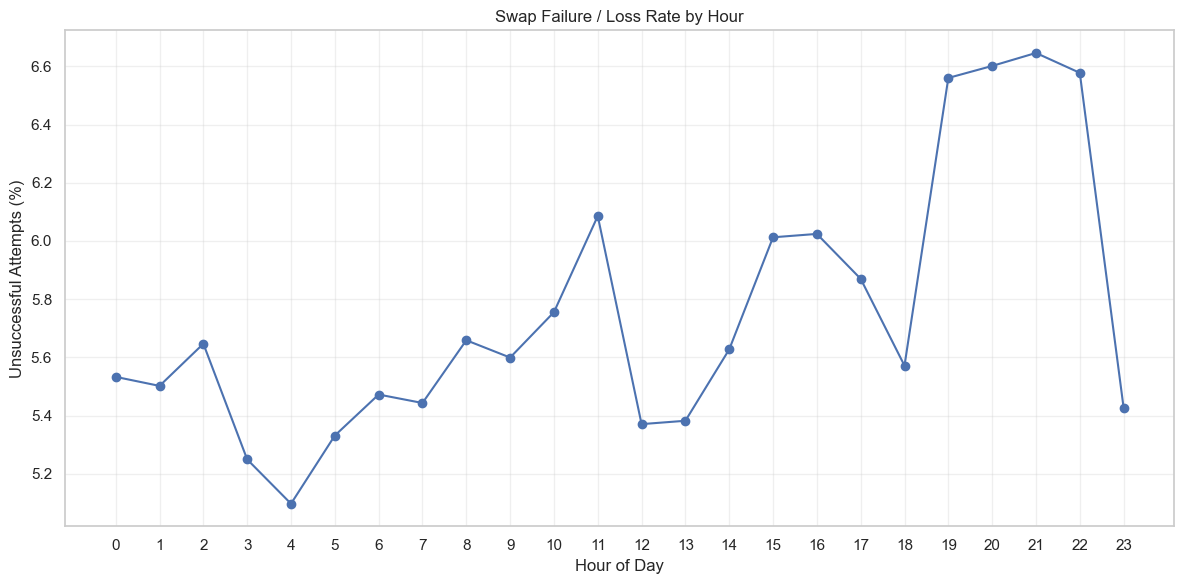

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_failure["hour"],
    hourly_failure["failure_rate_pct"],
    marker="o"
)

plt.title("Swap Failure / Loss Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Unsuccessful Attempts (%)")
plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT
    / "outputs"
    / "charts"
    / "hourly_failure_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
# ============================================================
# 5. STATION & CITY PERFORMANCE
# ============================================================

import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

stations_file = PROJECT_ROOT / "data" / "stations.csv"

stations = pd.read_csv(
    stations_file,
    low_memory=False
)

print("Stations dataset columns:")
print(stations.columns.tolist())

print("\nFirst 5 rows:")
display(stations.head())

Stations dataset columns:
['station_id', 'city', 'zone', 'latitude', 'longitude', 'location_type', 'host_type', 'commissioned_date', 'decommissioned_date', 'expansion_wave', 'charger_generation', 'slots_2w', 'slots_3w', 'inventory_target_2w', 'inventory_target_3w', 'monthly_rent_inr', 'monthly_maintenance_inr', 'grid_tariff_inr_kwh', 'connectivity_tier', 'firmware_version', 'firmware_updated_date', 'competitor_within_1_5km_since']

First 5 rows:


,station_id,city,zone,latitude,longitude,location_type,host_type,commissioned_date,decommissioned_date,expansion_wave,charger_generation,slots_2w,slots_3w,inventory_target_2w,inventory_target_3w,monthly_rent_inr,monthly_maintenance_inr,grid_tariff_inr_kwh,connectivity_tier,firmware_version,firmware_updated_date,competitor_within_1_5km_since
0,STN-BLR-001,Bengaluru,BLR-Electronic City,12.926943,77.604655,transit_hub,mall_parking,2023-12-09,NaN,Launch,Gen1,12,6,32,7,23247,5436,9.29,good,v3.2.1,2025-04-14,NaN
1,STN-BLR-002,Bengaluru,BLR-Central,13.149199,77.530565,commercial_hub,kirana,2023-06-20,NaN,Launch,Gen2,16,0,38,0,23201,5249,8.41,poor,v3.2.1,2025-04-14,NaN
2,STN-BLR-003,Bengaluru,BLR-Electronic City,12.917986,77.607560,commercial_hub,fuel_retailer,2023-09-26,NaN,Launch,Gen2,16,0,43,0,10281,4516,8.66,good,v3.2.1,2025-04-14,NaN
3,STN-BLR-004,Bengaluru,BLR-Whitefield,13.030901,77.489397,market,mall_parking,2023-08-25,NaN,Launch,Gen1,16,0,33,0,12322,5802,9.19,good,v3.2.1,2025-04-14,NaN
4,STN-BLR-005,Bengaluru,BLR-North,12.815864,77.628712,residential,mall_parking,2023-11-07,NaN,Launch,Gen1,12,0,15,0,24194,7134,8.68,fair,v3.2.1,2025-04-14,NaN


In [36]:
# ============================================================
# STATION + CITY PERFORMANCE ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

# ------------------------------------------------------------
# Load station metadata
# ------------------------------------------------------------

stations_file = PROJECT_ROOT / "data" / "stations.csv"

stations = pd.read_csv(
    stations_file,
    low_memory=False
)

# ------------------------------------------------------------
# Aggregate station-hour data to station level
# ------------------------------------------------------------

station_performance = (
    station_hour
    .groupby("station_id", as_index=False)
    .agg(
        total_attempts=("total_attempts", "sum"),
        completed_swaps=("completed_swaps", "sum"),
        failed_no_battery=("failed_no_battery", "sum"),
        failed_system=("failed_system", "sum"),
        abandoned=("abandoned", "sum"),
        cancelled=("cancelled", "sum"),
        unsuccessful=("unsuccessful", "sum")
    )
)

# Calculate station-level rates
station_performance["failure_rate_pct"] = (
    station_performance["unsuccessful"]
    / station_performance["total_attempts"]
    * 100
)

station_performance["completion_rate_pct"] = (
    station_performance["completed_swaps"]
    / station_performance["total_attempts"]
    * 100
)

# ------------------------------------------------------------
# Merge with station characteristics
# ------------------------------------------------------------

station_analysis = station_performance.merge(
    stations,
    on="station_id",
    how="left"
)

# ------------------------------------------------------------
# Remove test stations
# ------------------------------------------------------------

station_analysis = station_analysis[
    ~station_analysis["station_id"]
    .astype(str)
    .str.contains("TST", case=False, na=False)
].copy()

# ------------------------------------------------------------
# Save station-level analysis
# ------------------------------------------------------------

output_dir = PROJECT_ROOT / "outputs" / "tables"
output_dir.mkdir(parents=True, exist_ok=True)

station_analysis.to_csv(
    output_dir / "station_performance_analysis.csv",
    index=False
)

print("Station performance analysis completed! ✅")

print(
    f"Stations analysed: {len(station_analysis)}"
)

display(
    station_analysis[
        [
            "station_id",
            "city",
            "location_type",
            "charger_generation",
            "connectivity_tier",
            "expansion_wave",
            "total_attempts",
            "completed_swaps",
            "unsuccessful",
            "failure_rate_pct",
            "completion_rate_pct"
        ]
    ].head(20)
)

Station performance analysis completed! ✅
Stations analysed: 150


,station_id,city,location_type,charger_generation,connectivity_tier,expansion_wave,total_attempts,completed_swaps,unsuccessful,failure_rate_pct,completion_rate_pct
0,STN-BLR-001,Bengaluru,transit_hub,Gen1,good,Launch,26253,25006,1247,4.749933,95.250067
1,STN-BLR-002,Bengaluru,commercial_hub,Gen2,poor,Launch,30916,29568,1348,4.360202,95.639798
2,STN-BLR-003,Bengaluru,commercial_hub,Gen2,good,Launch,40241,38521,1720,4.274248,95.725752
3,STN-BLR-004,Bengaluru,market,Gen1,good,Launch,52094,49670,2424,4.653127,95.346873
4,STN-BLR-005,Bengaluru,residential,Gen1,fair,Launch,26380,25101,1279,4.848370,95.151630
5,STN-BLR-006,Bengaluru,commercial_hub,Gen1,poor,Launch,31159,29749,1410,4.525177,95.474823
6,STN-BLR-007,Bengaluru,commercial_hub,Gen2,poor,Launch,24075,23006,1069,4.440291,95.559709
7,STN-BLR-008,Bengaluru,market,Gen2,good,Launch,31225,29860,1365,4.371497,95.628503
8,STN-BLR-009,Bengaluru,commercial_hub,Gen1,good,Launch,39125,37327,1798,4.595527,95.404473
9,STN-BLR-010,Bengaluru,market,Gen2,fair,Launch,29975,28583,1392,4.643870,95.356130


In [37]:
# ============================================================
# CITY PERFORMANCE
# ============================================================

city_performance = (
    station_analysis
    .groupby("city", as_index=False)
    .agg(
        total_attempts=("total_attempts", "sum"),
        completed_swaps=("completed_swaps", "sum"),
        failed_no_battery=("failed_no_battery", "sum"),
        failed_system=("failed_system", "sum"),
        abandoned=("abandoned", "sum"),
        cancelled=("cancelled", "sum"),
        unsuccessful=("unsuccessful", "sum"),
        stations=("station_id", "nunique")
    )
)

city_performance["failure_rate_pct"] = (
    city_performance["unsuccessful"]
    / city_performance["total_attempts"]
    * 100
)

city_performance["completion_rate_pct"] = (
    city_performance["completed_swaps"]
    / city_performance["total_attempts"]
    * 100
)

city_performance = city_performance.sort_values(
    "failure_rate_pct",
    ascending=False
)

display(city_performance)

,city,total_attempts,completed_swaps,failed_no_battery,failed_system,abandoned,cancelled,unsuccessful,stations,failure_rate_pct,completion_rate_pct
3,Jaipur,487634,449366,23303,1374,11518,2073,38268,18,7.847689,92.152311
1,Delhi NCR,768913,712385,33892,2305,17030,3301,56528,30,7.351677,92.648323
2,Hyderabad,711930,664312,28274,2153,14158,3033,47618,26,6.688579,93.311421
5,Pune,552910,525331,15480,1647,8081,2371,27579,22,4.987973,95.012027
0,Bengaluru,763296,728563,18999,2318,10049,3367,34733,32,4.550397,95.449603
4,Mumbai,530299,506718,12838,1603,6827,2313,23581,22,4.446737,95.553263


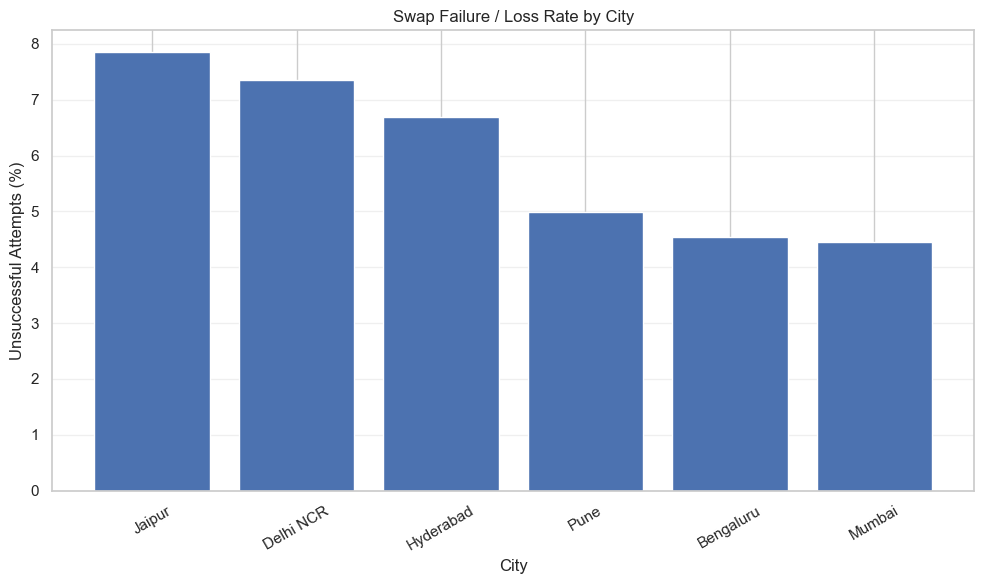

In [38]:
# ============================================================
# FAILURE RATE BY CITY
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    city_performance["city"],
    city_performance["failure_rate_pct"]
)

plt.title("Swap Failure / Loss Rate by City")
plt.xlabel("City")
plt.ylabel("Unsuccessful Attempts (%)")
plt.xticks(rotation=30)
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT
    / "outputs"
    / "charts"
    / "city_failure_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# ============================================================
# CHARGER GENERATION PERFORMANCE
# ============================================================

charger_performance = (
    station_analysis
    .groupby("charger_generation", as_index=False)
    .agg(
        stations=("station_id", "nunique"),
        total_attempts=("total_attempts", "sum"),
        completed_swaps=("completed_swaps", "sum"),
        unsuccessful=("unsuccessful", "sum"),
        failed_no_battery=("failed_no_battery", "sum"),
        failed_system=("failed_system", "sum")
    )
)

charger_performance["failure_rate_pct"] = (
    charger_performance["unsuccessful"]
    / charger_performance["total_attempts"]
    * 100
)

charger_performance["completion_rate_pct"] = (
    charger_performance["completed_swaps"]
    / charger_performance["total_attempts"]
    * 100
)

display(charger_performance)

,charger_generation,stations,total_attempts,completed_swaps,unsuccessful,failed_no_battery,failed_system,failure_rate_pct,completion_rate_pct
0,Gen1,51,1822034,1690298,131736,79144,5355,7.230161,92.769839
1,Gen2,62,1620707,1542159,78548,43565,4930,4.846527,95.153473
2,Gen3,37,372241,354218,18023,10077,1115,4.841756,95.158244


In [40]:
# ============================================================
# LOCATION TYPE PERFORMANCE
# ============================================================

location_performance = (
    station_analysis
    .groupby("location_type", as_index=False)
    .agg(
        stations=("station_id", "nunique"),
        total_attempts=("total_attempts", "sum"),
        completed_swaps=("completed_swaps", "sum"),
        unsuccessful=("unsuccessful", "sum"),
        failed_no_battery=("failed_no_battery", "sum"),
        abandoned=("abandoned", "sum"),
        cancelled=("cancelled", "sum")
    )
)

location_performance["failure_rate_pct"] = (
    location_performance["unsuccessful"]
    / location_performance["total_attempts"]
    * 100
)

location_performance["completion_rate_pct"] = (
    location_performance["completed_swaps"]
    / location_performance["total_attempts"]
    * 100
)

display(
    location_performance.sort_values(
        "failure_rate_pct",
        ascending=False
    )
)

,location_type,stations,total_attempts,completed_swaps,unsuccessful,failed_no_battery,abandoned,cancelled,failure_rate_pct,completion_rate_pct
2,market,47,1246931,1169179,77752,45343,23145,5445,6.235469,93.764531
0,commercial_hub,44,1535743,1440859,94884,55619,28254,6556,6.178378,93.821622
5,transit_hub,10,172667,162365,10302,5929,3064,769,5.966398,94.033602
3,residential,21,382274,361447,20827,11910,6077,1667,5.448186,94.551814
4,tech_park,7,147533,139843,7690,4389,2219,647,5.212393,94.787607
1,highway_fuel_pump,21,329834,312982,16852,9596,4904,1374,5.109237,94.890763


In [41]:
# ============================================================
# SERVICE FAILURES & CUSTOMER EXPERIENCE
# 1. QUEUE WAIT TIME BY OUTCOME
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = PROJECT_ROOT / "data" / "swap_events.csv"

wait_results = []

for chunk in pd.read_csv(
    file_path,
    chunksize=250_000,
    low_memory=False
):
    chunk["queue_wait_sec"] = pd.to_numeric(
        chunk["queue_wait_sec"],
        errors="coerce"
    )

    chunk["event_type"] = (
        chunk["event_type"]
        .astype("string")
        .str.strip()
    )

    # Keep only valid, non-negative queue waits
    chunk = chunk[
        chunk["queue_wait_sec"].notna() &
        (chunk["queue_wait_sec"] >= 0)
    ]

    wait_results.append(
        chunk[
            ["event_type", "queue_wait_sec"]
        ]
    )

wait_df = pd.concat(wait_results, ignore_index=True)

queue_summary = (
    wait_df
    .groupby("event_type")["queue_wait_sec"]
    .agg(
        attempts="count",
        mean_wait_sec="mean",
        median_wait_sec="median",
        p75_wait_sec=lambda x: x.quantile(0.75),
        p90_wait_sec=lambda x: x.quantile(0.90),
        p95_wait_sec=lambda x: x.quantile(0.95)
    )
    .reset_index()
)

queue_summary = queue_summary.sort_values(
    "median_wait_sec",
    ascending=False
)

queue_summary

,event_type,attempts,mean_wait_sec,median_wait_sec,p75_wait_sec,p90_wait_sec,p95_wait_sec
0,abandoned_queue,68533,702.557906,648.0,850.0,1087.0,1256.0
4,swap_completed,3645809,243.721747,209.0,304.0,424.0,518.0
1,cancelled_by_rider,16712,44.565701,44.0,67.0,81.0,85.0
3,failed_system_error,11570,44.417978,44.0,66.0,80.0,85.0
2,failed_no_charged_battery,134389,29.498121,30.0,44.0,53.0,57.0


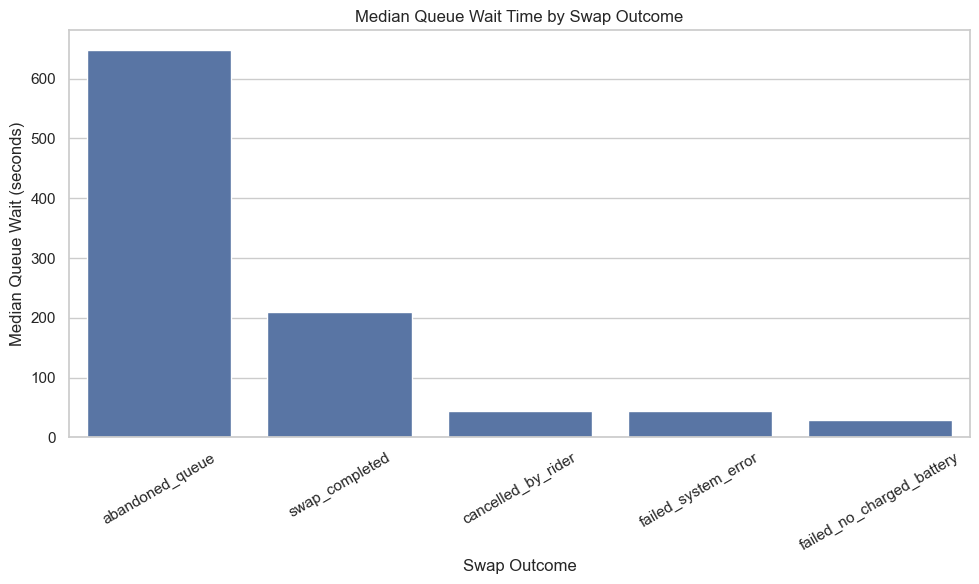

In [42]:
# ============================================================
# QUEUE WAIT TIME BY OUTCOME
# ============================================================

plot_df = queue_summary.copy()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x="event_type",
    y="median_wait_sec"
)

plt.title("Median Queue Wait Time by Swap Outcome")
plt.xlabel("Swap Outcome")
plt.ylabel("Median Queue Wait (seconds)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [43]:
# ============================================================
# BATTERY & EQUIPMENT ANALYSIS
# 1. BATTERY SOH VS DELIVERED RANGE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

battery_file = PROJECT_ROOT / "data" / "batteries.csv"

batteries = pd.read_csv(battery_file)

print("Shape:", batteries.shape)
print("\nColumns:")
print(batteries.columns.tolist())

batteries.head()

Shape: (6500, 13)

Columns:
['battery_id', 'pack_type', 'supplier', 'manufacturing_lot', 'manufacture_date', 'commission_date', 'rated_capacity_kwh', 'purchase_cost_inr', 'initial_soh_pct', 'bms_firmware', 'retired_date', 'retirement_reason', 'current_soh_pct']


,battery_id,pack_type,supplier,manufacturing_lot,manufacture_date,commission_date,rated_capacity_kwh,purchase_cost_inr,initial_soh_pct,bms_firmware,retired_date,retirement_reason,current_soh_pct
0,BAT-2W-100000,2W_2.1kWh,Cellora,CE-2503,2025-01-30,2025-03-19,2.1,31018,99.9,BMS-4.1,NaN,NaN,79.5
1,BAT-2W-100001,2W_2.1kWh,Cellora,CE-2403,2024-02-27,2024-03-30,2.1,34111,99.2,BMS-4.2,NaN,NaN,79.5
2,BAT-3W-100002,3W_4.8kWh,Cellora,CE-2305,2023-04-15,2023-05-11,4.8,66521,99.5,BMS-4.1,NaN,NaN,87.0
3,BAT-2W-100003,2W_2.1kWh,Kyron,KY-2409,2024-09-28,2024-10-09,2.1,32753,99.5,BMS-4.1,2025-06-15,end_of_life,58.1
4,BAT-2W-100004,2W_2.1kWh,Kyron,KY-2407,2024-11-06,2024-11-21,2.1,31734,99.5,BMS-4.2,2025-06-15,end_of_life,60.6


In [44]:
# Check missing values and data types

battery_quality = pd.DataFrame({
    "Data Type": batteries.dtypes.astype(str),
    "Missing Count": batteries.isna().sum(),
    "Missing %": (batteries.isna().mean() * 100).round(2),
    "Unique Values": batteries.nunique()
})

battery_quality

,Data Type,Missing Count,Missing %,Unique Values
battery_id,str,0,0.00,6500
pack_type,str,0,0.00,2
supplier,str,0,0.00,3
manufacturing_lot,str,0,0.00,55
manufacture_date,str,0,0.00,862
commission_date,str,0,0.00,826
rated_capacity_kwh,float64,0,0.00,2
purchase_cost_inr,int64,0,0.00,4111
initial_soh_pct,float64,0,0.00,23
bms_firmware,str,0,0.00,3


In [45]:
# Inspect numerical columns

batteries.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
battery_id,6500,6500,BAT-2W-100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pack_type,6500,2,2W_2.1kWh,5518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
supplier,6500,3,Cellora,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
manufacturing_lot,6500,55,KY-2408,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
manufacture_date,6500,862,2024-10-10,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
commission_date,6500,826,2024-09-13,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rated_capacity_kwh,6500.0,NaN,NaN,NaN,2.507908,0.967009,2.1,2.1,2.1,2.1,4.8
purchase_cost_inr,6500.0,NaN,NaN,NaN,37414.073538,12951.496627,27473.0,31339.5,32250.0,33397.25,75037.0
initial_soh_pct,6500.0,NaN,NaN,NaN,99.191292,0.39747,97.8,98.9,99.2,99.5,100.0
bms_firmware,6500,3,BMS-4.1,2197,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
# ============================================================
# BATTERY & EQUIPMENT ANALYSIS
# 1. CURRENT BATTERY SOH DISTRIBUTION
# ============================================================

# Convert SOH to numeric
batteries["current_soh_pct"] = pd.to_numeric(
    batteries["current_soh_pct"],
    errors="coerce"
)

# Create SOH health bands
def soh_band(soh):
    if soh < 60:
        return "<60%"
    elif soh < 70:
        return "60–69%"
    elif soh < 80:
        return "70–79%"
    elif soh < 90:
        return "80–89%"
    else:
        return "90%+"

batteries["soh_band"] = batteries["current_soh_pct"].apply(soh_band)

soh_summary = (
    batteries
    .groupby("soh_band")
    .agg(
        batteries=("battery_id", "count"),
        avg_soh=("current_soh_pct", "mean")
    )
    .reset_index()
)

soh_summary["share_pct"] = (
    soh_summary["batteries"] /
    soh_summary["batteries"].sum() * 100
).round(2)

soh_summary

,soh_band,batteries,avg_soh,share_pct
0,60–69%,921,61.990988,14.17
1,70–79%,2064,79.153585,31.75
2,80–89%,2998,82.440494,46.12
3,<60%,517,58.745648,7.95


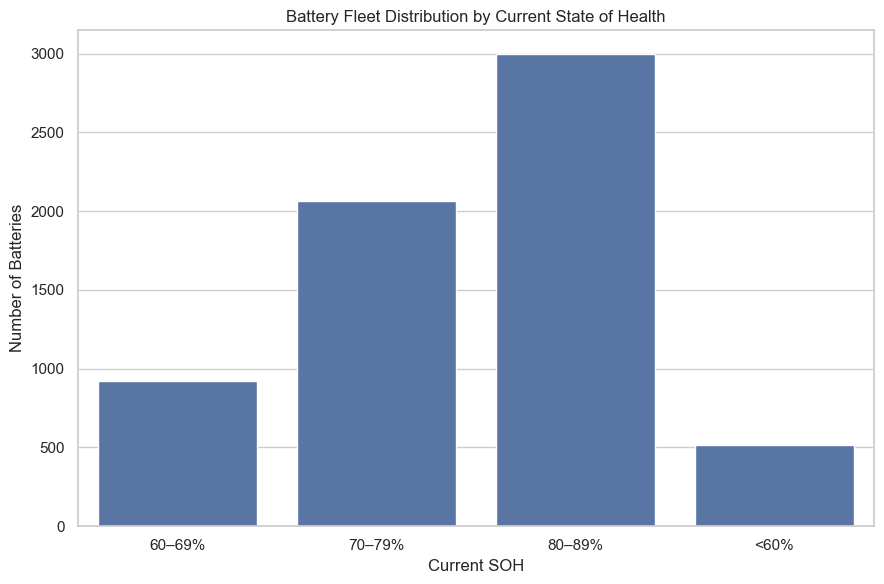

In [47]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=soh_summary,
    x="soh_band",
    y="batteries"
)

plt.title("Battery Fleet Distribution by Current State of Health")
plt.xlabel("Current SOH")
plt.ylabel("Number of Batteries")

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# SOH BY SUPPLIER
# ============================================================

supplier_soh = (
    batteries
    .groupby("supplier")
    .agg(
        batteries=("battery_id", "count"),
        avg_current_soh=("current_soh_pct", "mean"),
        median_current_soh=("current_soh_pct", "median"),
        retired_batteries=("retired_date", "count")
    )
    .reset_index()
)

supplier_soh["retirement_rate_pct"] = (
    supplier_soh["retired_batteries"] /
    supplier_soh["batteries"] * 100
).round(2)

supplier_soh

,supplier,batteries,avg_current_soh,median_current_soh,retired_batteries,retirement_rate_pct
0,Amptek,1307,81.005203,80.2,0,0.00
1,Cellora,3555,80.929030,80.2,0,0.00
2,Kyron,1638,63.747436,61.0,1438,87.79


In [49]:
# ============================================================
# BATTERY & EQUIPMENT ANALYSIS
# 2. BATTERY SWAP FREQUENCY
# ============================================================

swap_file = PROJECT_ROOT / "data" / "swap_events.csv"

battery_usage = {}

for chunk in pd.read_csv(
    swap_file,
    chunksize=250_000,
    low_memory=False
):
    # Count batteries entering the station
    in_counts = (
        chunk["battery_in_id"]
        .dropna()
        .astype(str)
        .value_counts()
    )

    # Count batteries going out to riders
    out_counts = (
        chunk["battery_out_id"]
        .dropna()
        .astype(str)
        .value_counts()
    )

    for battery_id, count in in_counts.items():
        battery_usage.setdefault(battery_id, {})
        battery_usage[battery_id]["swaps_in"] = (
            battery_usage[battery_id].get("swaps_in", 0) + count
        )

    for battery_id, count in out_counts.items():
        battery_usage.setdefault(battery_id, {})
        battery_usage[battery_id]["swaps_out"] = (
            battery_usage[battery_id].get("swaps_out", 0) + count
        )

battery_usage_df = (
    pd.DataFrame.from_dict(
        battery_usage,
        orient="index"
    )
    .fillna(0)
    .reset_index()
    .rename(columns={"index": "battery_id"})
)

battery_usage_df["total_swap_involvement"] = (
    battery_usage_df["swaps_in"] +
    battery_usage_df["swaps_out"]
)

battery_usage_df.head()

,battery_id,swaps_in,swaps_out,total_swap_involvement
0,BAT-2W-103850,664,630,1294
1,BAT-2W-101750,650,638,1288
2,BAT-2W-103564,642,669,1311
3,BAT-2W-101026,621,662,1283
4,BAT-2W-100546,673,659,1332


In [50]:
# Merge usage with battery information

battery_analysis = batteries.merge(
    battery_usage_df,
    on="battery_id",
    how="left"
)

battery_analysis[
    [
        "battery_id",
        "supplier",
        "manufacturing_lot",
        "current_soh_pct",
        "retired_date",
        "swaps_in",
        "swaps_out",
        "total_swap_involvement"
    ]
].head()

,battery_id,supplier,manufacturing_lot,current_soh_pct,retired_date,swaps_in,swaps_out,total_swap_involvement
0,BAT-2W-100000,Cellora,CE-2503,79.5,NaN,678,687,1365
1,BAT-2W-100001,Cellora,CE-2403,79.5,NaN,661,632,1293
2,BAT-3W-100002,Cellora,CE-2305,87.0,NaN,426,396,822
3,BAT-2W-100003,Kyron,KY-2409,58.1,2025-06-15,578,419,997
4,BAT-2W-100004,Kyron,KY-2407,60.6,2025-06-15,538,405,943


In [51]:
# ============================================================
# SWAP FREQUENCY BY BATTERY SOH
# ============================================================

soh_usage_summary = (
    battery_analysis
    .groupby("soh_band")
    .agg(
        batteries=("battery_id", "count"),
        avg_soh=("current_soh_pct", "mean"),
        avg_swap_involvement=("total_swap_involvement", "mean"),
        median_swap_involvement=("total_swap_involvement", "median")
    )
    .reset_index()
)

soh_usage_summary

,soh_band,batteries,avg_soh,avg_swap_involvement,median_swap_involvement
0,60–69%,921,61.990988,928.194354,933.0
1,70–79%,2064,79.153585,1313.184593,1318.0
2,80–89%,2998,82.440494,1143.570380,1268.0
3,<60%,517,58.745648,968.735010,968.0


In [52]:
# ============================================================
# SUPPLIER VS BATTERY USAGE
# ============================================================

supplier_usage = (
    battery_analysis
    .groupby("supplier")
    .agg(
        batteries=("battery_id", "count"),
        avg_soh=("current_soh_pct", "mean"),
        avg_swaps=("total_swap_involvement", "mean"),
        median_swaps=("total_swap_involvement", "median")
    )
    .reset_index()
)

supplier_usage

,supplier,batteries,avg_soh,avg_swaps,median_swaps
0,Amptek,1307,81.005203,1224.322877,1293.0
1,Cellora,3555,80.929030,1230.782841,1295.0
2,Kyron,1638,63.747436,927.299756,939.0


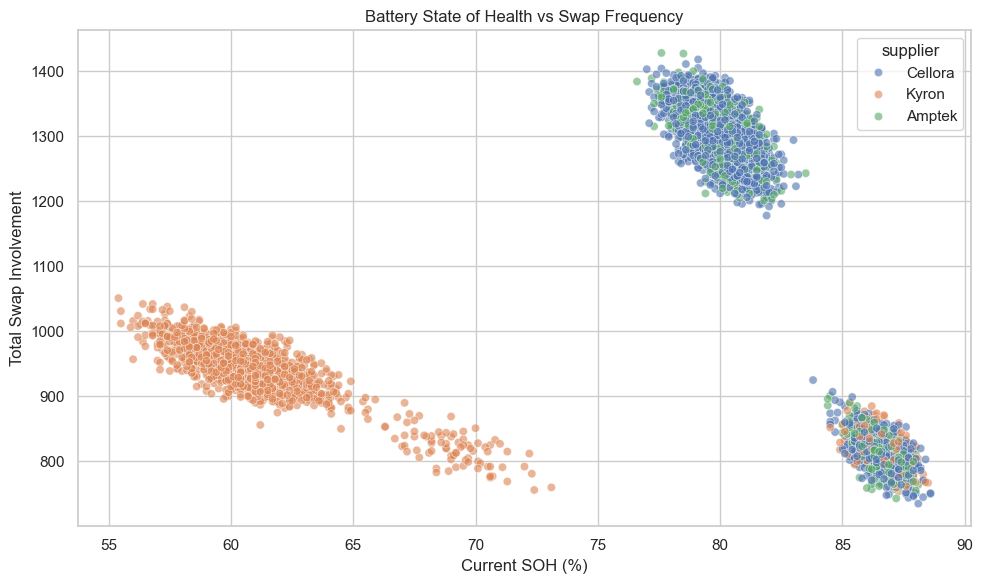

In [53]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=battery_analysis,
    x="current_soh_pct",
    y="total_swap_involvement",
    hue="supplier",
    alpha=0.6
)

plt.title("Battery State of Health vs Swap Frequency")
plt.xlabel("Current SOH (%)")
plt.ylabel("Total Swap Involvement")

plt.tight_layout()
plt.show()

In [54]:
# ============================================================
# BATTERY & EQUIPMENT ANALYSIS
# 3. MANUFACTURING LOT PERFORMANCE
# ============================================================

lot_summary = (
    battery_analysis
    .groupby(["supplier", "manufacturing_lot"])
    .agg(
        batteries=("battery_id", "count"),
        avg_current_soh=("current_soh_pct", "mean"),
        median_current_soh=("current_soh_pct", "median"),
        avg_swap_involvement=("total_swap_involvement", "mean"),
        retired_batteries=("retired_date", "count")
    )
    .reset_index()
)

lot_summary["retirement_rate_pct"] = (
    lot_summary["retired_batteries"] /
    lot_summary["batteries"] * 100
).round(2)

lot_summary = lot_summary.sort_values(
    "avg_current_soh"
)

lot_summary.head(15)

,supplier,manufacturing_lot,batteries,avg_current_soh,median_current_soh,avg_swap_involvement,retired_batteries,retirement_rate_pct
45,Kyron,KY-2409,481,60.915177,60.8,941.384615,473,98.34
43,Kyron,KY-2407,480,60.986042,60.6,940.335417,476,99.17
44,Kyron,KY-2408,500,61.048400,60.7,939.824000,489,97.80
20,Cellora,CE-2307,143,80.598601,80.1,1253.678322,0,0.00
7,Amptek,AM-2410,81,80.602469,80.2,1253.777778,0,0.00
29,Cellora,CE-2404,158,80.612658,80.0,1252.575949,0,0.00
23,Cellora,CE-2310,117,80.617094,80.1,1256.170940,0,0.00
30,Cellora,CE-2405,127,80.636220,80.3,1250.543307,0,0.00
2,Amptek,AM-2405,88,80.636364,79.9,1241.034091,0,0.00
19,Cellora,CE-2306,122,80.650000,80.2,1251.147541,0,0.00


In [55]:
# Lots with meaningful fleet size
lot_usage = lot_summary[
    lot_summary["batteries"] >= 50
].copy()

lot_usage.sort_values(
    "avg_swap_involvement",
    ascending=False
).head(15)

,supplier,manufacturing_lot,batteries,avg_current_soh,median_current_soh,avg_swap_involvement,retired_batteries,retirement_rate_pct
23,Cellora,CE-2310,117,80.617094,80.1,1256.170940,0,0.0
7,Amptek,AM-2410,81,80.602469,80.2,1253.777778,0,0.0
20,Cellora,CE-2307,143,80.598601,80.1,1253.678322,0,0.0
29,Cellora,CE-2404,158,80.612658,80.0,1252.575949,0,0.0
19,Cellora,CE-2306,122,80.650000,80.2,1251.147541,0,0.0
30,Cellora,CE-2405,127,80.636220,80.3,1250.543307,0,0.0
24,Cellora,CE-2311,133,80.721805,80.1,1244.060150,0,0.0
25,Cellora,CE-2312,137,80.707299,80.0,1243.788321,0,0.0
10,Amptek,AM-2501,90,80.694444,80.0,1242.177778,0,0.0
18,Cellora,CE-2305,131,80.870229,80.2,1241.755725,0,0.0


In [58]:
lot_usage.sort_values(
    ["avg_current_soh", "retirement_rate_pct"],
    ascending=[True, False]
).head(15)

,supplier,manufacturing_lot,batteries,avg_current_soh,median_current_soh,avg_swap_involvement,retired_batteries,retirement_rate_pct
45,Kyron,KY-2409,481,60.915177,60.8,941.384615,473,98.34
43,Kyron,KY-2407,480,60.986042,60.6,940.335417,476,99.17
44,Kyron,KY-2408,500,61.048400,60.7,939.824000,489,97.80
20,Cellora,CE-2307,143,80.598601,80.1,1253.678322,0,0.00
7,Amptek,AM-2410,81,80.602469,80.2,1253.777778,0,0.00
29,Cellora,CE-2404,158,80.612658,80.0,1252.575949,0,0.00
23,Cellora,CE-2310,117,80.617094,80.1,1256.170940,0,0.00
30,Cellora,CE-2405,127,80.636220,80.3,1250.543307,0,0.00
2,Amptek,AM-2405,88,80.636364,79.9,1241.034091,0,0.00
19,Cellora,CE-2306,122,80.650000,80.2,1251.147541,0,0.00


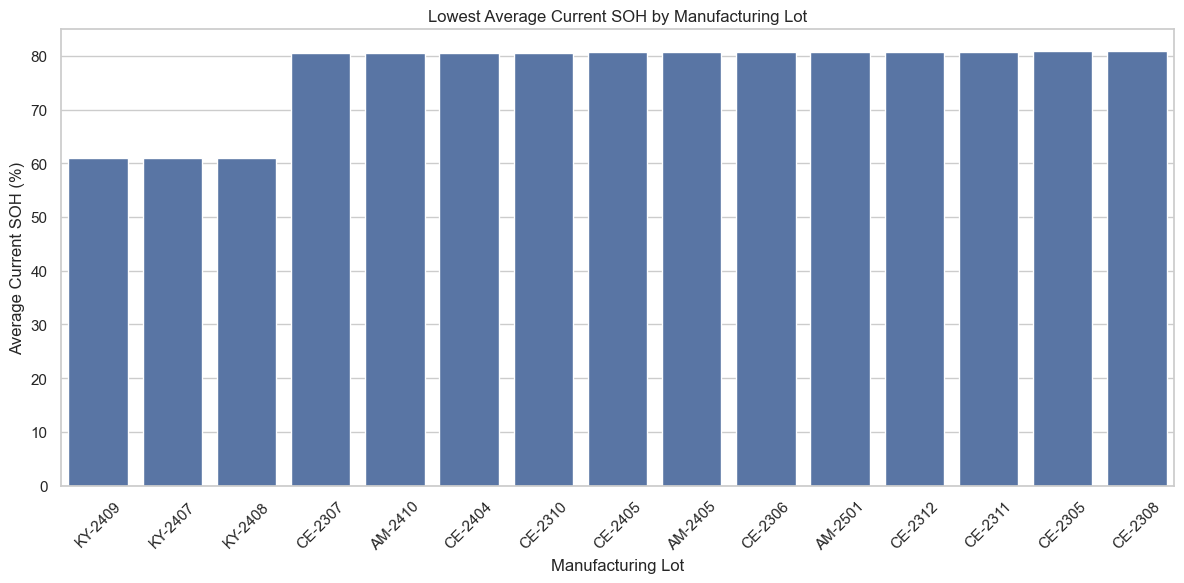

In [57]:
plt.figure(figsize=(12, 6))

top_lots = lot_usage.nsmallest(
    15,
    "avg_current_soh"
)

sns.barplot(
    data=top_lots,
    x="manufacturing_lot",
    y="avg_current_soh"
)

plt.title("Lowest Average Current SOH by Manufacturing Lot")
plt.xlabel("Manufacturing Lot")
plt.ylabel("Average Current SOH (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [59]:
# ============================================================
# PRICING & PARTNER ECONOMICS
# 1. PRICING & REVENUE BY TARIFF
# ============================================================

swap_file = PROJECT_ROOT / "data" / "swap_events.csv"

pricing_results = []

for chunk in pd.read_csv(
    swap_file,
    chunksize=250_000,
    low_memory=False
):
    # Keep completed swaps for realized revenue analysis
    chunk = chunk[
        chunk["event_type"].astype("string").str.strip()
        == "swap_completed"
    ].copy()

    # Convert numeric fields
    numeric_cols = [
        "list_price_inr",
        "discount_inr",
        "amount_charged_inr",
        "energy_to_recharge_kwh"
    ]

    for col in numeric_cols:
        chunk[col] = pd.to_numeric(
            chunk[col],
            errors="coerce"
        )

    summary = (
        chunk
        .groupby("tariff_code")
        .agg(
            completed_swaps=("event_id", "count"),
            total_list_price=("list_price_inr", "sum"),
            total_discount=("discount_inr", "sum"),
            total_revenue=("amount_charged_inr", "sum"),
            total_energy_kwh=("energy_to_recharge_kwh", "sum"),
            avg_list_price=("list_price_inr", "mean"),
            avg_discount=("discount_inr", "mean"),
            avg_amount_charged=("amount_charged_inr", "mean")
        )
        .reset_index()
    )

    pricing_results.append(summary)

pricing_summary = (
    pd.concat(pricing_results)
    .groupby("tariff_code")
    .agg(
        completed_swaps=("completed_swaps", "sum"),
        total_list_price=("total_list_price", "sum"),
        total_discount=("total_discount", "sum"),
        total_revenue=("total_revenue", "sum"),
        total_energy_kwh=("total_energy_kwh", "sum")
    )
    .reset_index()
)

pricing_summary["avg_list_price"] = (
    pricing_summary["total_list_price"] /
    pricing_summary["completed_swaps"]
)

pricing_summary["avg_discount"] = (
    pricing_summary["total_discount"] /
    pricing_summary["completed_swaps"]
)

pricing_summary["avg_amount_charged"] = (
    pricing_summary["total_revenue"] /
    pricing_summary["completed_swaps"]
)

pricing_summary["discount_rate_pct"] = (
    pricing_summary["total_discount"] /
    pricing_summary["total_list_price"] * 100
)

pricing_summary["revenue_per_kwh"] = (
    pricing_summary["total_revenue"] /
    pricing_summary["total_energy_kwh"]
)

pricing_summary.round(2)

,tariff_code,completed_swaps,total_list_price,total_discount,total_revenue,total_energy_kwh,avg_list_price,avg_discount,avg_amount_charged,discount_rate_pct,revenue_per_kwh
0,OFFPEAK,36098,2438035.0,0.00,2.149346e+06,67812.87,67.54,0.00,59.54,0.00,31.70
1,PARTNER,2409841,167994585.0,21228532.45,1.487535e+08,5218187.14,69.71,8.81,61.73,12.64,28.51
2,PEAK,169833,11472360.0,0.00,1.401990e+07,319217.22,67.55,0.00,82.55,0.00,43.92
3,STD,1030037,68203320.0,0.00,6.820330e+07,2025179.61,66.21,0.00,66.21,0.00,33.68


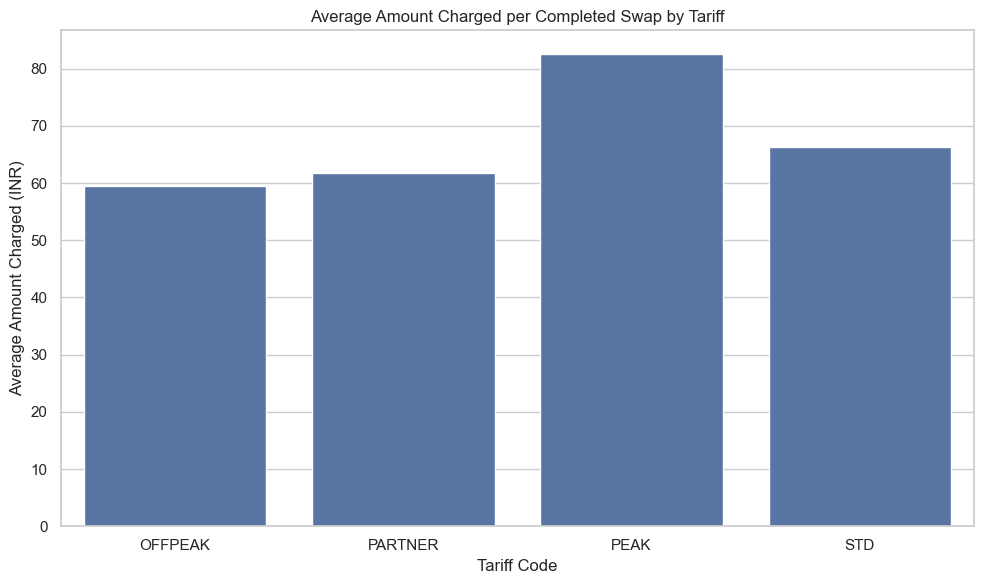

In [60]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=pricing_summary,
    x="tariff_code",
    y="avg_amount_charged"
)

plt.title("Average Amount Charged per Completed Swap by Tariff")
plt.xlabel("Tariff Code")
plt.ylabel("Average Amount Charged (INR)")

plt.tight_layout()
plt.show()

In [61]:
# ============================================================
# PRICING & PARTNER ECONOMICS
# 2. ESTIMATED CONTRIBUTION MARGIN
# ============================================================

stations_file = PROJECT_ROOT / "data" / "stations.csv"

stations = pd.read_csv(stations_file)

print(stations[
    ["station_id", "city", "grid_tariff_inr_kwh"]
].head())

print("\nGrid tariff summary:")
print(stations["grid_tariff_inr_kwh"].describe())

    station_id       city  grid_tariff_inr_kwh
0  STN-BLR-001  Bengaluru                 9.29
1  STN-BLR-002  Bengaluru                 8.41
2  STN-BLR-003  Bengaluru                 8.66
3  STN-BLR-004  Bengaluru                 9.19
4  STN-BLR-005  Bengaluru                 8.68

Grid tariff summary:
count    152.000000
mean       9.301579
std        0.772910
min        7.500000
25%        8.785000
50%        9.215000
75%        9.787500
max       11.700000
Name: grid_tariff_inr_kwh, dtype: float64


In [64]:
margin_results = []

for chunk in pd.read_csv(
    swap_file,
    chunksize=250_000,
    low_memory=False
):
    chunk = chunk[
        chunk["event_type"].astype("string").str.strip()
        == "swap_completed"
    ].copy()

    chunk["amount_charged_inr"] = pd.to_numeric(
        chunk["amount_charged_inr"],
        errors="coerce"
    )

    chunk["energy_to_recharge_kwh"] = pd.to_numeric(
        chunk["energy_to_recharge_kwh"],
        errors="coerce"
    )

    # Keep only fields needed for margin calculation
    temp = chunk[
        [
            "station_id",
            "tariff_code",
            "amount_charged_inr",
            "energy_to_recharge_kwh"
        ]
    ]

    temp = temp.merge(
        stations[
            [
                "station_id",
                "grid_tariff_inr_kwh"
            ]
        ],
        on="station_id",
        how="left"
    )

    # Estimated electricity cost
    temp["energy_cost_inr"] = (
        temp["energy_to_recharge_kwh"] *
        temp["grid_tariff_inr_kwh"]
    )

    # Contribution before other operating costs
    temp["estimated_contribution_inr"] = (
        temp["amount_charged_inr"] -
        temp["energy_cost_inr"]
    )

    margin_results.append(
        temp.groupby("tariff_code").agg(
            completed_swaps=("amount_charged_inr", "count"),
            revenue=("amount_charged_inr", "sum"),
            energy_cost=("energy_cost_inr", "sum"),
            contribution=("estimated_contribution_inr", "sum")
        ).reset_index()
    )

margin_summary = (
    pd.concat(margin_results)
    .groupby("tariff_code")
    .agg(
        completed_swaps=("completed_swaps", "sum"),
        revenue=("revenue", "sum"),
        energy_cost=("energy_cost", "sum"),
        contribution=("contribution", "sum")
    )
    .reset_index()
)

margin_summary["revenue_per_swap"] = (
    margin_summary["revenue"] /
    margin_summary["completed_swaps"]
)

margin_summary["energy_cost_per_swap"] = (
    margin_summary["energy_cost"] /
    margin_summary["completed_swaps"]
)

margin_summary["contribution_per_swap"] = (
    margin_summary["contribution"] /
    margin_summary["completed_swaps"]
)

margin_summary["contribution_margin_pct"] = (
    margin_summary["contribution"] /
    margin_summary["revenue"] * 100
)

margin_summary.round(2)

,tariff_code,completed_swaps,revenue,energy_cost,contribution,revenue_per_swap,energy_cost_per_swap,contribution_per_swap,contribution_margin_pct
0,OFFPEAK,36098,2.149346e+06,625938.41,1.523408e+06,59.54,17.34,42.20,70.88
1,PARTNER,2409841,1.487535e+08,48622032.80,1.001315e+08,61.73,20.18,41.55,67.31
2,PEAK,169833,1.401990e+07,2944097.10,1.107580e+07,82.55,17.34,65.22,79.00
3,STD,1030037,6.820330e+07,18895057.80,4.930824e+07,66.21,18.34,47.87,72.30


In [65]:
# ============================================================
# PRICING & PARTNER ECONOMICS
# 3. FLEET PARTNER DATA OVERVIEW
# ============================================================

partner_file = PROJECT_ROOT / "data" / "fleet_partners.csv"

fleet_partners = pd.read_csv(partner_file)

print("Shape:", fleet_partners.shape)
print("\nColumns:")
print(fleet_partners.columns.tolist())

fleet_partners.head()

Shape: (12, 12)

Columns:
['partner_id', 'partner_name', 'partner_segment', 'vehicle_class', 'contract_type', 'contract_start_date', 'discount_pct', 'amendment_date', 'discount_pct_after_amendment', 'peak_surcharge_billable', 'payment_terms_days', 'cities_active']


,partner_id,partner_name,partner_segment,vehicle_class,contract_type,contract_start_date,discount_pct,amendment_date,discount_pct_after_amendment,peak_surcharge_billable,payment_terms_days,cities_active
0,FP-01,FeastFly,food_delivery,2W,volume_tiered,2023-04-01,10.0,NaN,NaN,Y,30,BLR|DEL|HYD|PUN|MUM|JAI
1,FP-02,ParcelNest,ecom_logistics,2W,pay_per_swap,2023-07-01,15.0,NaN,NaN,Y,30,BLR|DEL|HYD|MUM
2,FP-03,ZipDrop,quick_commerce,2W,volume_tiered,2023-06-01,12.0,2024-11-01,28.0,N,45,BLR|DEL|HYD|PUN|MUM|JAI
3,FP-04,CargoTuk,cargo_3w,3W,pay_per_swap,2023-09-01,8.0,NaN,NaN,Y,30,DEL|HYD|JAI
4,FP-05,Swiggle Go,food_delivery,2W,volume_tiered,2023-05-01,11.0,NaN,NaN,N,30,BLR|PUN|MUM


In [66]:
fleet_partners.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
partner_id,12,12,FP-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
partner_name,12,12,FeastFly,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
partner_segment,12,5,food_delivery,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_class,12,3,2W,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract_type,12,2,pay_per_swap,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract_start_date,12,12,2023-04-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discount_pct,12.0,NaN,NaN,NaN,9.416667,2.84312,5.0,7.75,9.5,11.25,15.0
amendment_date,1,1,2024-11-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discount_pct_after_amendment,1.0,NaN,NaN,NaN,28.0,NaN,28.0,28.0,28.0,28.0,28.0
peak_surcharge_billable,12,2,Y,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
# ============================================================
# PRICING & PARTNER ECONOMICS
# 4. FLEET PARTNER PERFORMANCE
# ============================================================

riders_file = PROJECT_ROOT / "data" / "riders.csv"

riders = pd.read_csv(riders_file)

print("Rider columns:")
print(riders.columns.tolist())

riders.head()

Rider columns:
['rider_id', 'partner_id', 'vehicle_class', 'vehicle_model', 'home_zone', 'signup_date', 'signup_channel', 'plan_type', 'declared_shift', 'age_band', 'kyc_verified', 'home_city']


,rider_id,partner_id,vehicle_class,vehicle_model,home_zone,signup_date,signup_channel,plan_type,declared_shift,age_band,kyc_verified,home_city
0,RD-1000000,FP-04,3W,Kranti Cargo3,DEL-Noida,2023-03-08,field_agent,partner_billed,night,45+,True,Delhi NCR
1,RD-1000001,FP-05,2W,Volt Cub,MUM-Thane,2023-03-08,partner_onboarding,partner_billed,mixed,35-44,True,Mumbai
2,RD-1000002,FP-06,2W,Torq X1,HYD-West,2023-03-08,partner_onboarding,partner_billed,evening,25-34,False,Hyderabad
3,RD-1000003,FP-01,2W,Zipp E2,MUM-Navi Mumbai,2023-03-08,partner_onboarding,partner_billed,evening,25-34,True,Mumbai
4,RD-1000004,FP-02,2W,Zipp E2,HYD-Hitech City,2023-03-08,partner_onboarding,partner_billed,night,NaN,True,Hyderabad


In [68]:
# Check whether riders contain partner information

print(
    riders[
        [col for col in riders.columns if "partner" in col.lower()]
    ].head()
)

  partner_id
0      FP-04
1      FP-05
2      FP-06
3      FP-01
4      FP-02


In [69]:
# ============================================================
# PRICING & PARTNER ECONOMICS
# 4. FLEET PARTNER PERFORMANCE
# ============================================================

# Find the partner column in riders
partner_cols = [
    col for col in riders.columns
    if "partner" in col.lower()
]

print("Partner-related rider columns:", partner_cols)

# Use partner_id if available
if "partner_id" in riders.columns:
    rider_partner_col = "partner_id"
else:
    rider_partner_col = partner_cols[0]

print("Using:", rider_partner_col)

# Keep only the fields needed for the join
rider_partner_map = riders[
    ["rider_id", rider_partner_col]
].copy()

rider_partner_map = rider_partner_map.rename(
    columns={rider_partner_col: "partner_id"}
)

# Process completed swaps
partner_results = []

for chunk in pd.read_csv(
    swap_file,
    chunksize=250_000,
    low_memory=False
):
    chunk["event_type"] = (
        chunk["event_type"]
        .astype("string")
        .str.strip()
    )

    chunk = chunk[
        chunk["event_type"] == "swap_completed"
    ].copy()

    chunk["amount_charged_inr"] = pd.to_numeric(
        chunk["amount_charged_inr"],
        errors="coerce"
    )

    chunk["energy_to_recharge_kwh"] = pd.to_numeric(
        chunk["energy_to_recharge_kwh"],
        errors="coerce"
    )

    # Connect rider to fleet partner
    chunk = chunk.merge(
        rider_partner_map,
        on="rider_id",
        how="left"
    )

    # Keep partner transactions only
    chunk = chunk[
        chunk["partner_id"].notna()
    ].copy()

    if len(chunk) == 0:
        continue

    summary = (
        chunk
        .groupby("partner_id")
        .agg(
            completed_swaps=("event_id", "count"),
            revenue=("amount_charged_inr", "sum"),
            energy_kwh=("energy_to_recharge_kwh", "sum")
        )
        .reset_index()
    )

    partner_results.append(summary)

partner_actual = (
    pd.concat(partner_results)
    .groupby("partner_id")
    .agg(
        completed_swaps=("completed_swaps", "sum"),
        revenue=("revenue", "sum"),
        energy_kwh=("energy_kwh", "sum")
    )
    .reset_index()
)

# Add partner contract information
partner_actual = partner_actual.merge(
    fleet_partners,
    on="partner_id",
    how="left"
)

partner_actual["revenue_per_swap"] = (
    partner_actual["revenue"] /
    partner_actual["completed_swaps"]
)

partner_actual["estimated_discount_inr"] = (
    partner_actual["revenue"] *
    partner_actual["discount_pct"] /
    (100 - partner_actual["discount_pct"])
)

partner_actual = partner_actual.sort_values(
    "completed_swaps",
    ascending=False
)

partner_actual[
    [
        "partner_id",
        "partner_name",
        "partner_segment",
        "vehicle_class",
        "contract_type",
        "discount_pct",
        "completed_swaps",
        "revenue",
        "revenue_per_swap"
    ]
]

Partner-related rider columns: ['partner_id']
Using: partner_id


,partner_id,partner_name,partner_segment,vehicle_class,contract_type,discount_pct,completed_swaps,revenue,revenue_per_swap
2,FP-03,ZipDrop,quick_commerce,2W,volume_tiered,12.0,557172,29015711.20,52.076758
0,FP-01,FeastFly,food_delivery,2W,volume_tiered,10.0,526620,32696006.00,62.086525
1,FP-02,ParcelNest,ecom_logistics,2W,pay_per_swap,15.0,302506,17113714.75,56.573142
4,FP-05,Swiggle Go,food_delivery,2W,volume_tiered,11.0,241689,14336840.65,59.319376
3,FP-04,CargoTuk,cargo_3w,3W,pay_per_swap,8.0,134085,13333431.20,99.440140
6,FP-07,QuickCart,quick_commerce,2W,pay_per_swap,9.0,129967,8062439.00,62.034509
5,FP-06,RideMitra,bike_taxi,2W,pay_per_swap,6.0,120695,7569963.90,62.719780
7,FP-08,DabbaXpress,food_delivery,2W,pay_per_swap,8.0,93376,5953223.20,63.755389
11,FP-12,UrbanErrand,bike_taxi,2W,pay_per_swap,5.0,83854,5322144.75,63.469182
9,FP-10,MetroMove,ecom_logistics,mixed,volume_tiered,12.0,83500,4922457.00,58.951581


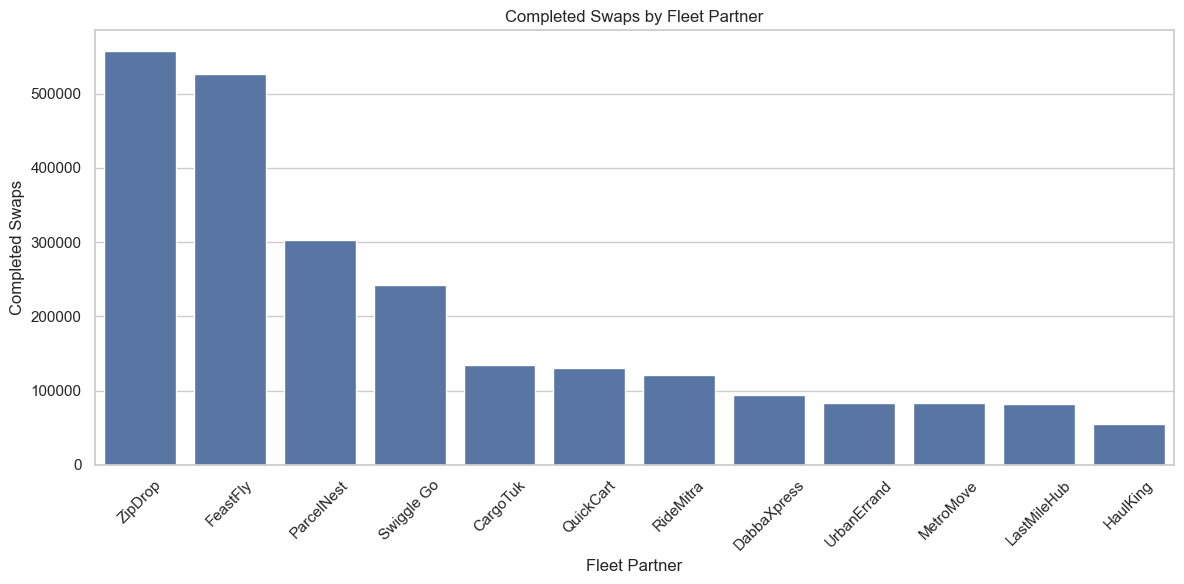

In [70]:
# ============================================================
# PARTNER SWAP VOLUME
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=partner_actual,
    x="partner_name",
    y="completed_swaps"
)

plt.title("Completed Swaps by Fleet Partner")
plt.xlabel("Fleet Partner")
plt.ylabel("Completed Swaps")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [71]:
# ============================================================
# RIDER RETENTION ANALYSIS
# 1. RIDER DATA OVERVIEW
# ============================================================

print("Shape:", riders.shape)

print("\nColumns:")
print(riders.columns.tolist())

riders.head()

Shape: (20000, 12)

Columns:
['rider_id', 'partner_id', 'vehicle_class', 'vehicle_model', 'home_zone', 'signup_date', 'signup_channel', 'plan_type', 'declared_shift', 'age_band', 'kyc_verified', 'home_city']


,rider_id,partner_id,vehicle_class,vehicle_model,home_zone,signup_date,signup_channel,plan_type,declared_shift,age_band,kyc_verified,home_city
0,RD-1000000,FP-04,3W,Kranti Cargo3,DEL-Noida,2023-03-08,field_agent,partner_billed,night,45+,True,Delhi NCR
1,RD-1000001,FP-05,2W,Volt Cub,MUM-Thane,2023-03-08,partner_onboarding,partner_billed,mixed,35-44,True,Mumbai
2,RD-1000002,FP-06,2W,Torq X1,HYD-West,2023-03-08,partner_onboarding,partner_billed,evening,25-34,False,Hyderabad
3,RD-1000003,FP-01,2W,Zipp E2,MUM-Navi Mumbai,2023-03-08,partner_onboarding,partner_billed,evening,25-34,True,Mumbai
4,RD-1000004,FP-02,2W,Zipp E2,HYD-Hitech City,2023-03-08,partner_onboarding,partner_billed,night,NaN,True,Hyderabad


In [72]:
rider_quality = pd.DataFrame({
    "Data Type": riders.dtypes.astype(str),
    "Missing Count": riders.isna().sum(),
    "Missing %": (riders.isna().mean() * 100).round(2),
    "Unique Values": riders.nunique()
})

rider_quality

,Data Type,Missing Count,Missing %,Unique Values
rider_id,str,0,0.00,20000
partner_id,str,7628,38.14,12
vehicle_class,str,0,0.00,2
vehicle_model,str,0,0.00,8
home_zone,str,0,0.00,28
signup_date,str,0,0.00,817
signup_channel,str,0,0.00,4
plan_type,str,0,0.00,3
declared_shift,str,3662,18.31,4
age_band,str,1547,7.74,4


In [73]:
# ============================================================
# RIDER RETENTION ANALYSIS
# 2. NEW RIDER RETURN RATE
# ============================================================

retention_results = []

for chunk in pd.read_csv(
    swap_file,
    chunksize=250_000,
    low_memory=False
):
    chunk["event_type"] = (
        chunk["event_type"]
        .astype("string")
        .str.strip()
    )

    # Only successful swaps
    chunk = chunk[
        chunk["event_type"] == "swap_completed"
    ].copy()

    chunk["event_ts"] = pd.to_datetime(
        chunk["event_ts"],
        errors="coerce"
    )

    retention_results.append(
        chunk[[
            "rider_id",
            "event_ts",
            "station_id",
            "queue_wait_sec",
            "tariff_code",
            "amount_charged_inr"
        ]]
    )

completed_swaps = pd.concat(
    retention_results,
    ignore_index=True
)

completed_swaps = completed_swaps.sort_values(
    ["rider_id", "event_ts"]
)

# First completed swap for each rider
first_swap = (
    completed_swaps
    .groupby("rider_id", as_index=False)
    .first()
)

first_swap = first_swap.rename(
    columns={
        "event_ts": "first_swap_ts",
        "station_id": "first_station_id",
        "queue_wait_sec": "first_queue_wait_sec",
        "tariff_code": "first_tariff_code",
        "amount_charged_inr": "first_amount_charged"
    }
)

# Number of completed swaps per rider
rider_swap_counts = (
    completed_swaps
    .groupby("rider_id")
    .size()
    .reset_index(name="completed_swap_count")
)

retention = first_swap.merge(
    rider_swap_counts,
    on="rider_id",
    how="left"
)

# Returned = more than one completed swap
retention["returned"] = (
    retention["completed_swap_count"] > 1
)

retention_summary = pd.DataFrame({
    "new_riders": [len(retention)],
    "returned_riders": [retention["returned"].sum()],
    "non_returned_riders": [
        (~retention["returned"]).sum()
    ]
})

retention_summary["return_rate_pct"] = (
    retention_summary["returned_riders"] /
    retention_summary["new_riders"] * 100
)

retention_summary["non_return_rate_pct"] = (
    retention_summary["non_returned_riders"] /
    retention_summary["new_riders"] * 100
)

retention_summary.round(2)

,new_riders,returned_riders,non_returned_riders,return_rate_pct,non_return_rate_pct
0,19948,19845,103,99.48,0.52


In [74]:
# Distribution of completed swaps per rider

retention["completed_swap_count"].describe()

count    19948.000000
mean       182.765641
std        155.393010
min          1.000000
25%         54.000000
50%        142.000000
75%        274.000000
max        879.000000
Name: completed_swap_count, dtype: float64

In [75]:
# Return status

retention["returned"].value_counts()

returned
True     19845
False      103
Name: count, dtype: int64

In [76]:
# ============================================================
# RIDER RETENTION ANALYSIS
# 3. RETURNED VS NON-RETURNED RIDERS
# ============================================================

retention["first_swap_date"] = (
    retention["first_swap_ts"].dt.date
)

# Overall comparison of first-swap characteristics
retention_comparison = (
    retention
    .groupby("returned")
    .agg(
        riders=("rider_id", "count"),
        avg_first_queue_wait_sec=("first_queue_wait_sec", "mean"),
        median_first_queue_wait_sec=("first_queue_wait_sec", "median"),
        avg_first_amount=("first_amount_charged", "mean")
    )
    .reset_index()
)

retention_comparison

,returned,riders,avg_first_queue_wait_sec,median_first_queue_wait_sec,avg_first_amount
0,False,103,281.640777,249.0,67.945631
1,True,19845,243.036432,210.0,65.043991


In [77]:
# First-swap tariff distribution by retention status

tariff_retention = pd.crosstab(
    retention["first_tariff_code"],
    retention["returned"],
    normalize="index"
) * 100

tariff_retention.round(2)

returned,False,True
first_tariff_code,,
OFFPEAK,0.00,100.00
PARTNER,0.55,99.45
PEAK,0.78,99.22
STD,0.44,99.56


In [ ]:
# First station distribution by retention status

station_retention = (
    retention
    .groupby(["first_station_id", "returned"])
    .size()
    .reset_index(name="riders")
)

station_retention.sort_values(
    "riders",
    ascending=False
).head(20)